## **NORMAL VS CRACKLE VS WHEEZE CLASSIFICATION USING STATISTICAL MODELS**

### **GENERAL RESULTS**

| Method                 | Accuracy          | Macro AUC         | Weighted F1 score |
|------------------------|------------------|------------------|-------------------|
| Baseline               | 0.710 ± 0.022    | 0.820 ± 0.027    | 0.715 ± 0.021     |
| Spectrum Correction    | 0.730 ± 0.008 (+2.8%) | 0.845 ± 0.013  |    0.728 ± 0.013               |
| DANN                   | 0.730 ± 0.018 (+2.8%) | 0.828 ± 0.024    | 0.725 ± 0.029     |
| **CDAN**               | **0.760 ± 0.014 (+7%)** | **0.868 ± 0.005** | **0.755 ± 0.024** |
| DANN με VAE (1 stage) | 0.751 ± 0.010 (+5.8%) | 0.840 ± 0.008    | 0.745 ± 0.017     |
| DANN με VAE (2 stages) | 0.753 ± 0.009 (+6.1%) | 0.848 ± 0.005    | 0.741 ± 0.008     |


### **METRICS PER CLASS**

#### **NORMAL**

| Method                 | F1 score         | Sensitivity       | Specificity       | Precision        | MCC             |
|-------------------------|------------------|------------------|------------------|------------------|-----------------|
| Baseline                | 0.783 ± 0.017    | 0.853 ± 0.073    | 0.610 ± 0.128    | 0.733 ± 0.035    | 0.458 ± 0.053   |
| Spectrum Correction     |  0.793 ± 0.005  |        0.838± 0.042    |    0.640 ± 0.080    |     0.758 ± 0.033             |         0.505 ± 0.027        |
| DANN                    | 0.795 ± 0.014    | **0.855 ± 0.037**    | 0.610 ± 0.098    | 0.748 ± 0.041    | 0.481 ± 0.059   |
| **CDAN**                | **0.813 ± 0.010**| 0.845 ± 0.039| 0.680 ± 0.098    | 0.780 ± 0.043    | **0.540 ± 0.036** |
| DANN με VAE (1 stage)  | 0.797 ± 0.008    | 0.783 ± 0.013    | **0.713 ± 0.005**| **0.785 ± 0.006**| 0.504 ± 0.013   |
| DANN με VAE (2 stages)  | 0.800 ± 0.008    | 0.798 ± 0.013    | 0.710 ± 0.008    | 0.783 ± 0.005    | 0.513 ± 0.010   |


#### **CRACKLE**

| Method                 | F1 score         | Sensitivity       | Specificity       | Precision        | MCC             |
|-------------------------|------------------|------------------|------------------|------------------|-----------------|
| Baseline                | 0.620 ± 0.050    | 0.620 ± 0.141    | 0.860 ± 0.074    | 0.668 ± 0.049    | 0.490 ± 0.062   |
| Spectrum Correction     |           0.653 ± 0.017       |       0.630 ± 0.070           |   0.880 ± 0.030  | 0.690 ± 0.040           |   0.528 ± 0.019  |
| DANN                    | 0.655 ± 0.057    | 0.610 ± 0.086    | **0.890 ± 0.025**    | 0.700 ± 0.045    | 0.510 ± 0.047   |
| **CDAN**                | **0.700 ± 0.035**| **0.685 ± 0.068**| 0.888 ± 0.021| **0.718 ± 0.019**| **0.584 ± 0.030** |
| DANN με VAE (1 stage)  | 0.673 ± 0.010    | 0.668 ± 0.010    | 0.873 ± 0.008    | 0.690 ± 0.013    | 0.543 ± 0.010   |
| DANN με VAE (2 stages)  | 0.680 ± 0.015    | 0.668 ± 0.022    | 0.873 ± 0.010    | 0.678 ± 0.005    | 0.543 ± 0.013   |


#### **WHEEZE**

| Method                 | F1 score         | Sensitivity       | Specificity       | Precision        | MCC             |
|-------------------------|------------------|------------------|------------------|------------------|-----------------|
| Baseline                | 0.595 ± 0.005    | 0.408 ± 0.083    | **0.978 ± 0.019**| 0.695 ± 0.067    | 0.495 ± 0.054   |
| Spectrum Correction     |   0.609 ± 0.034  |        0.513 ± 0.063           | 0.968 ± 0.010        | 0.715 ± 0.042           |  0.567 ± 0.025          |
| DANN                    | 0.565 ± 0.087    | 0.468 ± 0.109    | 0.975 ± 0.010    | 0.725 ± 0.034    | 0.525 ± 0.068   |
| CDAN                    | 0.630 ± 0.080    | 0.550 ± 0.136    | 0.975 ± 0.017    | **0.785 ± 0.105**| 0.605 ± 0.044   |
| DANN με VAE (1 stage)  | 0.663 ± 0.005    | 0.658 ± 0.026    | 0.953 ± 0.008    | 0.685 ± 0.024    | 0.608 ± 0.009   |
| **DANN με VAE (2 stages)** | **0.665 ± 0.009**| **0.653 ± 0.017**| 0.953 ± 0.005    | 0.675 ± 0.024    | **0.615 ± 0.005** |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

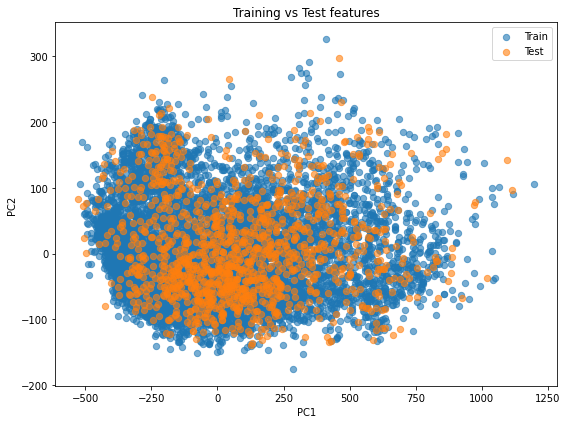

In [71]:
# Load train, test features
training_features = np.load("training_features_mean.npy")
test_features = np.load("test_features_mean.npy")

# Combine both sets
X_combined = np.vstack([training_features, test_features])
sets = np.array(["Train"] * len(training_features) + ["Test"] * len(test_features))

# PCA: retain 95% of variance
pca = PCA(n_components=0.95)
X_pca_full = pca.fit_transform(X_combined)

# Keep first 2 principal components for visualization
X_pca_vis = X_pca_full[:, :2]

plt.figure(figsize=(8, 6))
for set_name in ["Train", "Test"]:
    idx = sets == set_name
    plt.scatter(X_pca_vis[idx, 0], X_pca_vis[idx, 1], label=set_name, alpha=0.6, s=40)
plt.title("Training vs Test features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

From the PCA plot we observe a significant overlap between the training and test sets in the projected feature space. This suggests that both sets share a similar underlying distribution after feature extraction. As a result,the classification models trained on this feature representation are less likely to suffer from distribution mismatch.

First we load, scale and encode the labels from training and test sets. For the scaling we apply MinMax Scaler on the interval [-1, 1] and for te encoding Label Encoder.

In [3]:
X_train = np.load("training_features_mean.npy")
y_train = np.load("training_labels.npy")
X_test = np.load("test_features_mean.npy")
y_test = np.load("test_labels.npy")

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
classes = le.classes_

# Apply MinMax Scaling 
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

We start be finding the best combination of hyperparameters for each model using grid search.

Best n_neighbors (accuracy): 1 with accuracy: 0.7618
Best n_neighbors (F1 macro): 1 with F1-score: 0.7617


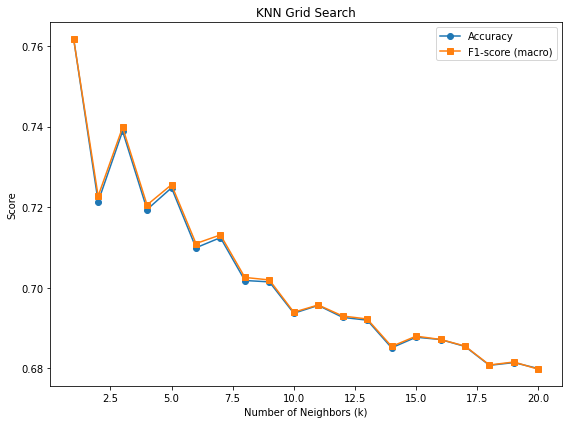

In [ ]:
from statistical_models.knn import knn_grid_search

knn_grid_search(X_train, y_train, n_splits=5, neighbor_range=range(1, 21))

Best params (accuracy): {'C': 10, 'gamma': 'scale'} acc=0.7086
Best params (F1 macro): {'C': 10, 'gamma': 'scale'} f1=0.7035


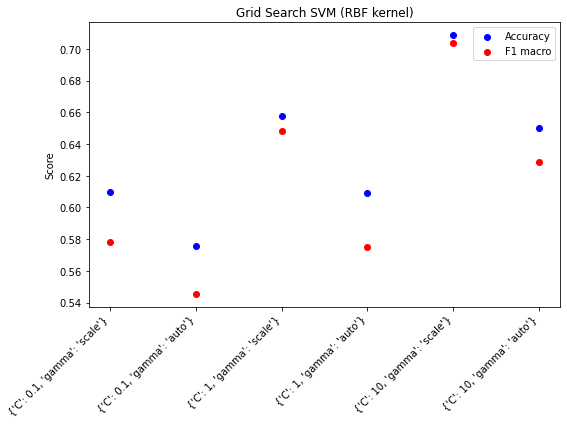

In [4]:
from statistical_models.non_linear_svm import grid_search_svm

param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"]
}

grid = grid_search_svm(X_train, y_train, param_grid, n_splits=5)

Best params (accuracy): {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200} acc=0.7554
Best params (F1 macro): {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200} f1=0.7521


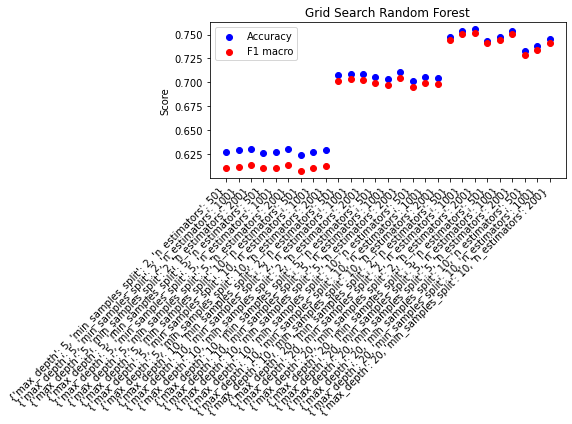

In [5]:
from statistical_models.random_forest import rf_grid_search

# Grid search
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 20],
    "min_samples_split": [2, 5, 10]
}

grid = rf_grid_search(X_train, y_train, param_grid, n_splits=5)

Best params (accuracy): {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200} acc=0.7687
Best params (F1 macro): {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200} f1=0.7668


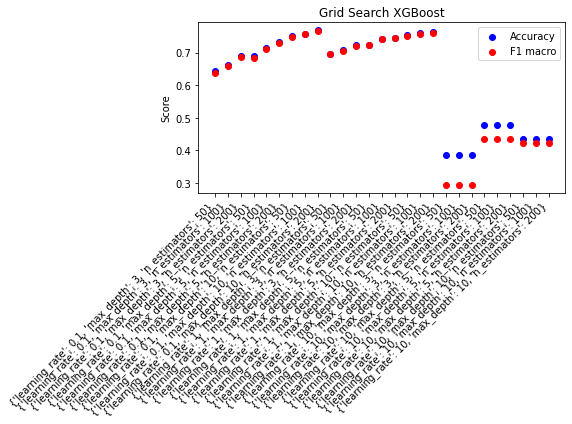

In [6]:
from statistical_models.xgboost import xgb_grid_search

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10],
    "learning_rate": [0.1, 1, 10]
}

grid_acc = xgb_grid_search(X_train, y_train, param_grid)

Keep the best hyperparameters after the grid search.

In [11]:
#k-NN
best_k = 3

# Non-Linear SVM
best_params_svm = {
    "C": 10,
    "gamma": 'scale'
}

# Random Forest
best_params_rf = {
    "n_estimators": 200,
    "max_depth": 20,
    "min_samples_split": 2
}

# XGBoost
best_params_xgb = {
    "n_estimators": 200,
    "max_depth": 10,
    "learning_rate": 0.1
}

### **BASELINE (WITHOUT DOMAIN ADAPTATION)**

#### **k-NN**


Fold 1


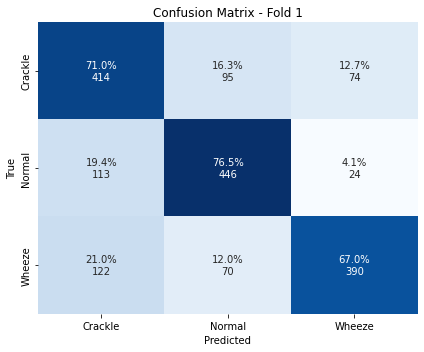

              precision    recall  f1-score   support

     Crackle       0.64      0.71      0.67       583
      Normal       0.73      0.77      0.75       583
      Wheeze       0.80      0.67      0.73       582

    accuracy                           0.72      1748
   macro avg       0.72      0.72      0.72      1748
weighted avg       0.72      0.72      0.72      1748


Fold 2


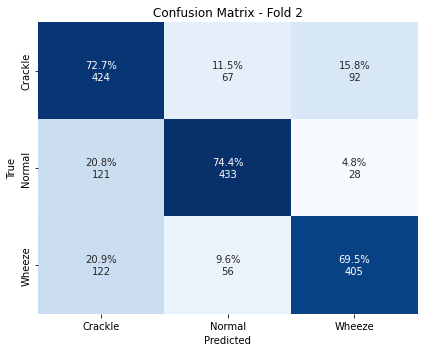

              precision    recall  f1-score   support

     Crackle       0.64      0.73      0.68       583
      Normal       0.78      0.74      0.76       582
      Wheeze       0.77      0.69      0.73       583

    accuracy                           0.72      1748
   macro avg       0.73      0.72      0.72      1748
weighted avg       0.73      0.72      0.72      1748


Fold 3


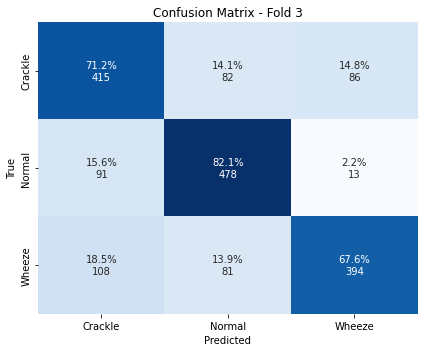

              precision    recall  f1-score   support

     Crackle       0.68      0.71      0.69       583
      Normal       0.75      0.82      0.78       582
      Wheeze       0.80      0.68      0.73       583

    accuracy                           0.74      1748
   macro avg       0.74      0.74      0.74      1748
weighted avg       0.74      0.74      0.74      1748


Fold 4


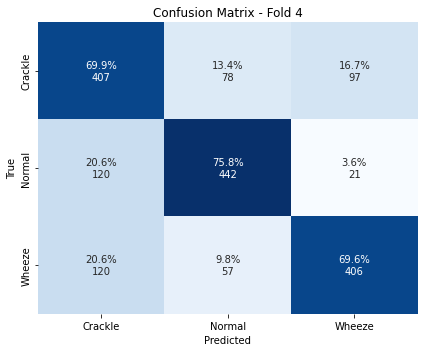

              precision    recall  f1-score   support

     Crackle       0.63      0.70      0.66       582
      Normal       0.77      0.76      0.76       583
      Wheeze       0.77      0.70      0.73       583

    accuracy                           0.72      1748
   macro avg       0.72      0.72      0.72      1748
weighted avg       0.72      0.72      0.72      1748


Fold 5


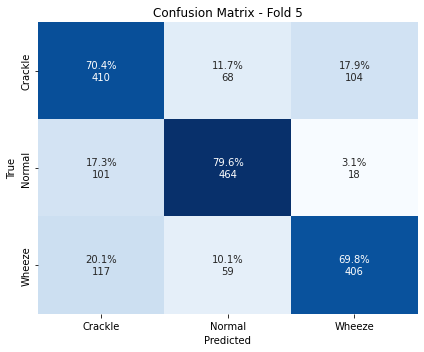

              precision    recall  f1-score   support

     Crackle       0.65      0.70      0.68       582
      Normal       0.79      0.80      0.79       583
      Wheeze       0.77      0.70      0.73       582

    accuracy                           0.73      1747
   macro avg       0.74      0.73      0.73      1747
weighted avg       0.74      0.73      0.73      1747



In [ ]:
from statistical_models.knn import *

# Training
knn_model = train(X_train, y_train, classes, n_neighbors=best_k)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.62      0.69      0.65       373
      Normal       0.77      0.79      0.78       729
      Wheeze       0.66      0.41      0.51       177

    accuracy                           0.71      1279
   macro avg       0.68      0.63      0.65      1279
weighted avg       0.71      0.71      0.71      1279



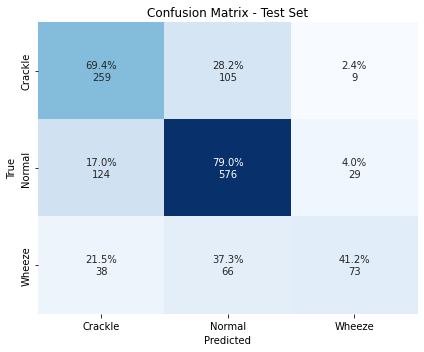

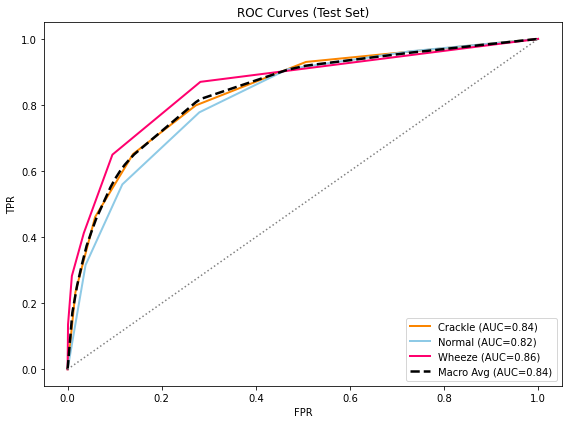

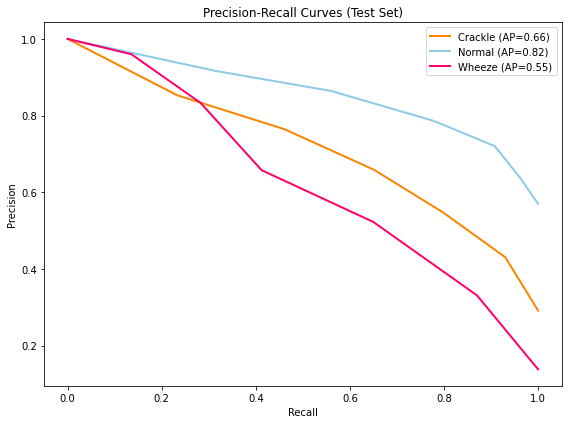

In [11]:
from statistical_models.evaluate import evaluate_model

# Evaluate on test set
knn_metrics_df = evaluate_model(X_test, y_test, classes, knn_model)

In [5]:
knn_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.817694,0.753863,0.577652,0.909454,0.527645,0.785779
1,Normal,0.732510,0.776364,0.812785,0.686495,0.504054,0.754437
2,Wheeze,0.440678,0.985481,0.829787,0.916456,0.563931,0.713079


#### **Non-Linear SVM (rbf kernel)**


Fold 1


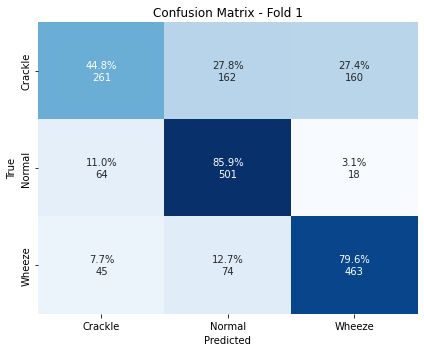

              precision    recall  f1-score   support

     Crackle       0.71      0.45      0.55       583
      Normal       0.68      0.86      0.76       583
      Wheeze       0.72      0.80      0.76       582

    accuracy                           0.70      1748
   macro avg       0.70      0.70      0.69      1748
weighted avg       0.70      0.70      0.69      1748


Fold 2


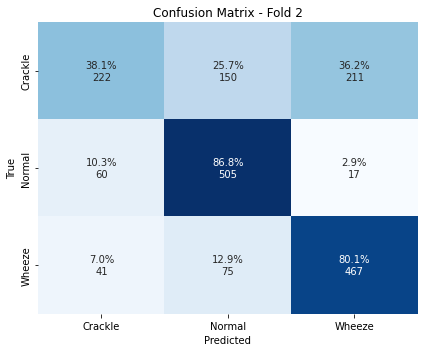

              precision    recall  f1-score   support

     Crackle       0.69      0.38      0.49       583
      Normal       0.69      0.87      0.77       582
      Wheeze       0.67      0.80      0.73       583

    accuracy                           0.68      1748
   macro avg       0.68      0.68      0.66      1748
weighted avg       0.68      0.68      0.66      1748


Fold 3


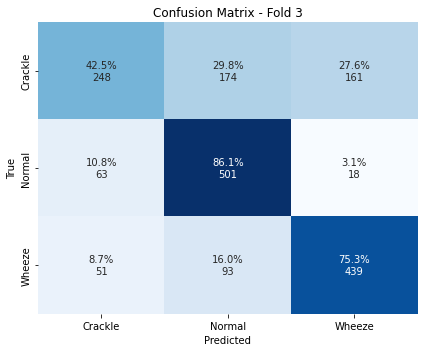

              precision    recall  f1-score   support

     Crackle       0.69      0.43      0.52       583
      Normal       0.65      0.86      0.74       582
      Wheeze       0.71      0.75      0.73       583

    accuracy                           0.68      1748
   macro avg       0.68      0.68      0.67      1748
weighted avg       0.68      0.68      0.67      1748


Fold 4


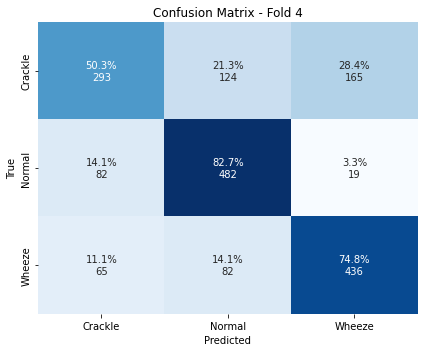

              precision    recall  f1-score   support

     Crackle       0.67      0.50      0.57       582
      Normal       0.70      0.83      0.76       583
      Wheeze       0.70      0.75      0.72       583

    accuracy                           0.69      1748
   macro avg       0.69      0.69      0.69      1748
weighted avg       0.69      0.69      0.69      1748


Fold 5


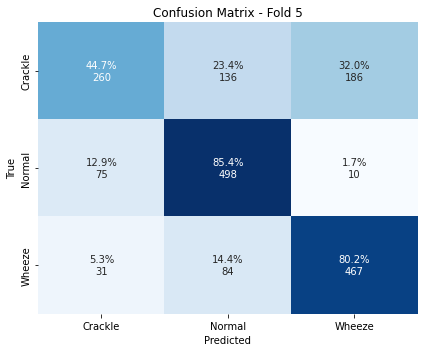

              precision    recall  f1-score   support

     Crackle       0.71      0.45      0.55       582
      Normal       0.69      0.85      0.77       583
      Wheeze       0.70      0.80      0.75       582

    accuracy                           0.70      1747
   macro avg       0.70      0.70      0.69      1747
weighted avg       0.70      0.70      0.69      1747



In [ ]:
from statistical_models.non_linear_svm import train

svm_model = train(X_train, y_train, classes, best_params_svm)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.63      0.50      0.55       373
      Normal       0.69      0.86      0.76       729
      Wheeze       0.79      0.35      0.49       177

    accuracy                           0.68      1279
   macro avg       0.70      0.57      0.60      1279
weighted avg       0.69      0.68      0.66      1279



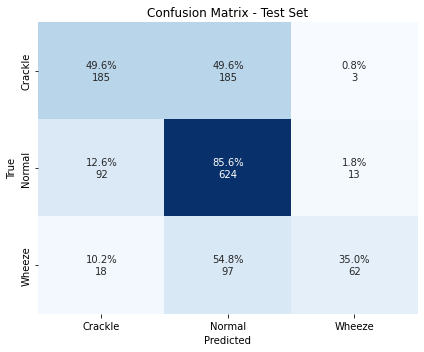

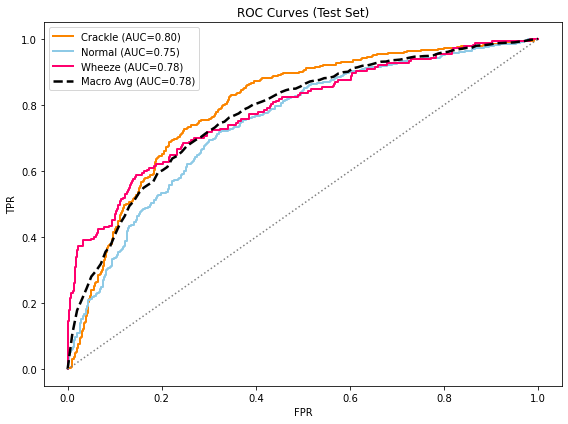

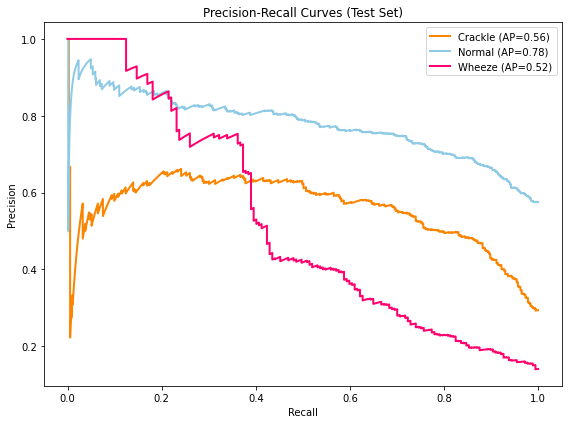

In [ ]:
from statistical_models.evaluate import evaluate_model

svm_metrics_df = evaluate_model(X_test, y_test, classes, svm_model)

In [103]:
svm_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.495979,0.878587,0.627119,0.808943,0.404146,0.687283
1,Normal,0.855967,0.487273,0.688742,0.718499,0.373873,0.671620
2,Wheeze,0.350282,0.985481,0.794872,0.904246,0.484498,0.667882


#### **Random Forest**


Fold 1


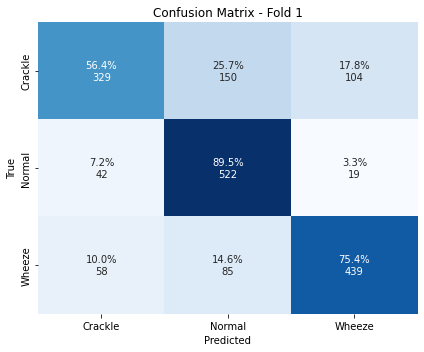

              precision    recall  f1-score   support

     Crackle       0.77      0.56      0.65       583
      Normal       0.69      0.90      0.78       583
      Wheeze       0.78      0.75      0.77       582

    accuracy                           0.74      1748
   macro avg       0.75      0.74      0.73      1748
weighted avg       0.75      0.74      0.73      1748


Fold 2


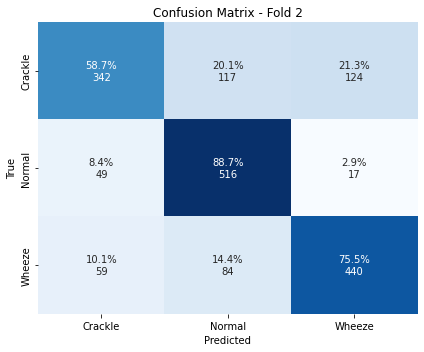

              precision    recall  f1-score   support

     Crackle       0.76      0.59      0.66       583
      Normal       0.72      0.89      0.79       582
      Wheeze       0.76      0.75      0.76       583

    accuracy                           0.74      1748
   macro avg       0.75      0.74      0.74      1748
weighted avg       0.75      0.74      0.74      1748


Fold 3


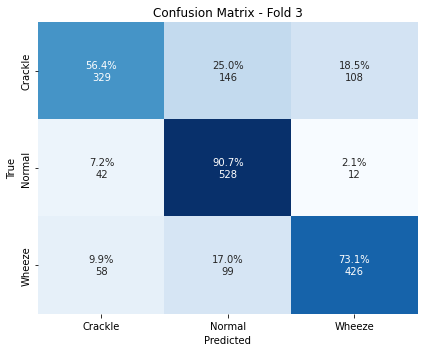

              precision    recall  f1-score   support

     Crackle       0.77      0.56      0.65       583
      Normal       0.68      0.91      0.78       582
      Wheeze       0.78      0.73      0.75       583

    accuracy                           0.73      1748
   macro avg       0.74      0.73      0.73      1748
weighted avg       0.74      0.73      0.73      1748


Fold 4


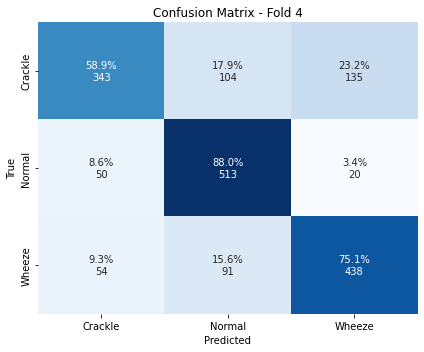

              precision    recall  f1-score   support

     Crackle       0.77      0.59      0.67       582
      Normal       0.72      0.88      0.79       583
      Wheeze       0.74      0.75      0.74       583

    accuracy                           0.74      1748
   macro avg       0.74      0.74      0.74      1748
weighted avg       0.74      0.74      0.74      1748


Fold 5


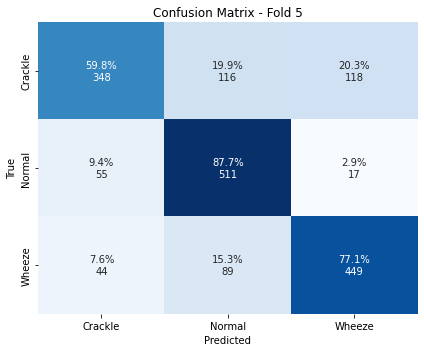

              precision    recall  f1-score   support

     Crackle       0.78      0.60      0.68       582
      Normal       0.71      0.88      0.79       583
      Wheeze       0.77      0.77      0.77       582

    accuracy                           0.75      1747
   macro avg       0.75      0.75      0.74      1747
weighted avg       0.75      0.75      0.74      1747



In [ ]:
from statistical_models.random_forest import train

rf_model = train(X_train, y_train, classes, best_params_rf)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.71      0.55      0.62       373
      Normal       0.72      0.90      0.80       729
      Wheeze       0.69      0.33      0.45       177

    accuracy                           0.72      1279
   macro avg       0.71      0.59      0.62      1279
weighted avg       0.71      0.72      0.70      1279



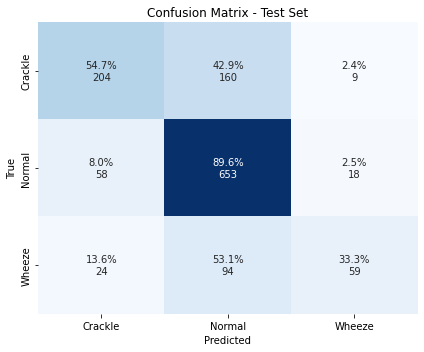

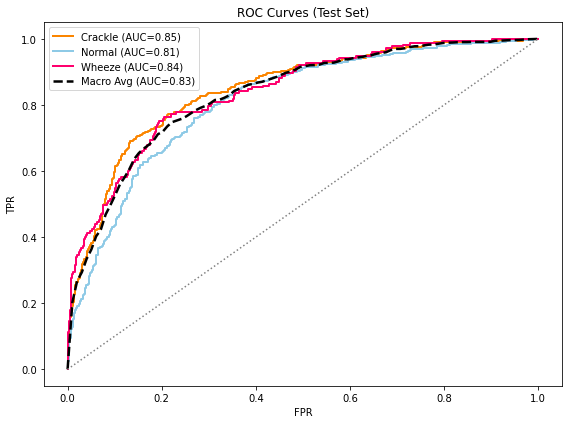

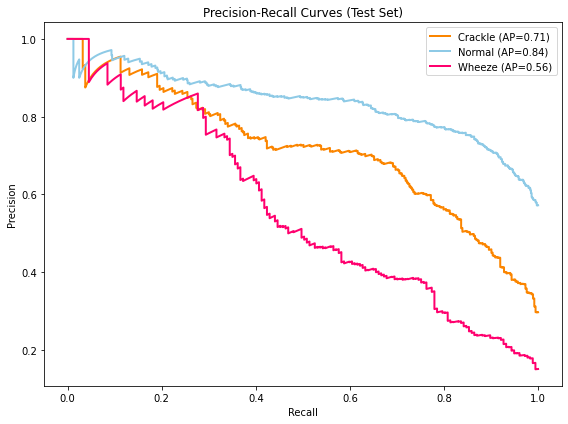

In [ ]:
from statistical_models.evaluate import evaluate_model

# Evaluate on test set
rf_metrics_df = evaluate_model(X_test, y_test, classes, rf_model)

In [44]:
rf_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.546917,0.909492,0.713287,0.829809,0.497869,0.728205
1,Normal,0.895748,0.538182,0.719956,0.795699,0.473030,0.716965
2,Wheeze,0.333333,0.975499,0.686047,0.901090,0.425825,0.654416


#### **XGBoost**


Fold 1


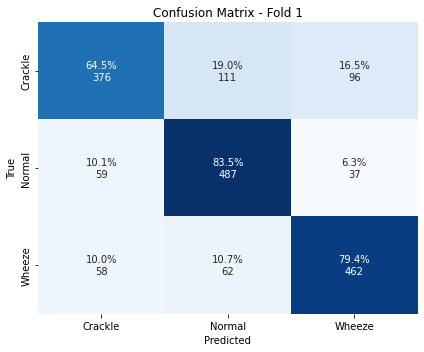

              precision    recall  f1-score   support

     Crackle       0.76      0.64      0.70       583
      Normal       0.74      0.84      0.78       583
      Wheeze       0.78      0.79      0.79       582

    accuracy                           0.76      1748
   macro avg       0.76      0.76      0.76      1748
weighted avg       0.76      0.76      0.76      1748


Fold 2


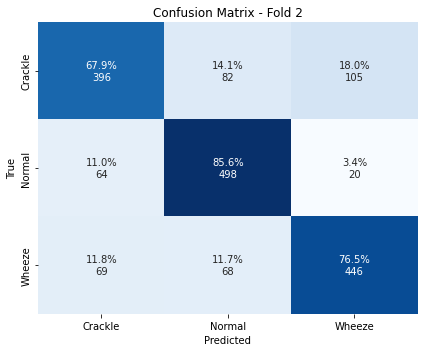

              precision    recall  f1-score   support

     Crackle       0.75      0.68      0.71       583
      Normal       0.77      0.86      0.81       582
      Wheeze       0.78      0.77      0.77       583

    accuracy                           0.77      1748
   macro avg       0.77      0.77      0.76      1748
weighted avg       0.77      0.77      0.76      1748


Fold 3


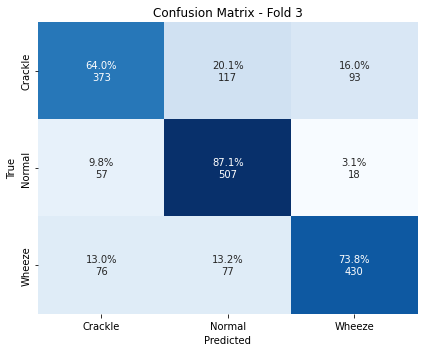

              precision    recall  f1-score   support

     Crackle       0.74      0.64      0.69       583
      Normal       0.72      0.87      0.79       582
      Wheeze       0.79      0.74      0.77       583

    accuracy                           0.75      1748
   macro avg       0.75      0.75      0.75      1748
weighted avg       0.75      0.75      0.75      1748


Fold 4


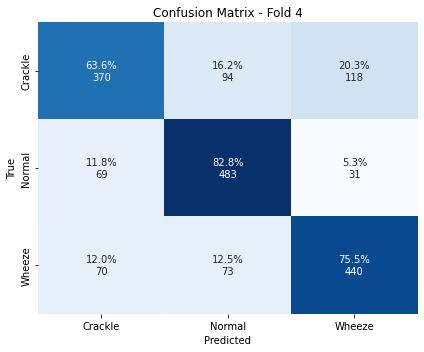

              precision    recall  f1-score   support

     Crackle       0.73      0.64      0.68       582
      Normal       0.74      0.83      0.78       583
      Wheeze       0.75      0.75      0.75       583

    accuracy                           0.74      1748
   macro avg       0.74      0.74      0.74      1748
weighted avg       0.74      0.74      0.74      1748


Fold 5


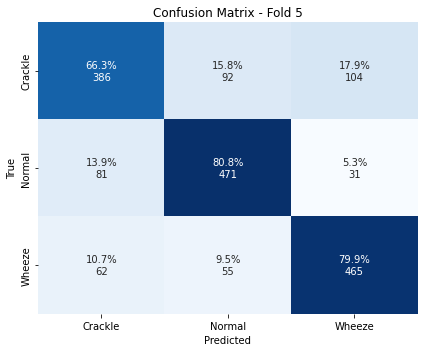

              precision    recall  f1-score   support

     Crackle       0.73      0.66      0.69       582
      Normal       0.76      0.81      0.78       583
      Wheeze       0.78      0.80      0.79       582

    accuracy                           0.76      1747
   macro avg       0.76      0.76      0.76      1747
weighted avg       0.76      0.76      0.76      1747



In [ ]:
from statistical_models.xgboost import train

#param_dict = {"n_estimators": 200, "max_depth": 5, "learning_rate": 1}
xgb_model = train(X_train, y_train, classes, best_params_xgb)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.71      0.61      0.66       373
      Normal       0.75      0.84      0.79       729
      Wheeze       0.64      0.51      0.57       177

    accuracy                           0.73      1279
   macro avg       0.70      0.65      0.67      1279
weighted avg       0.72      0.73      0.72      1279



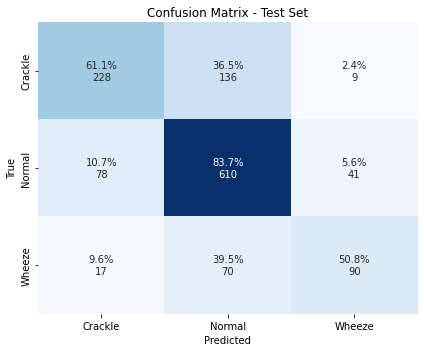

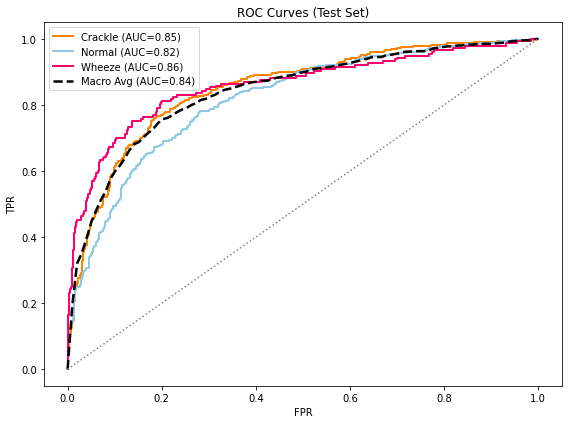

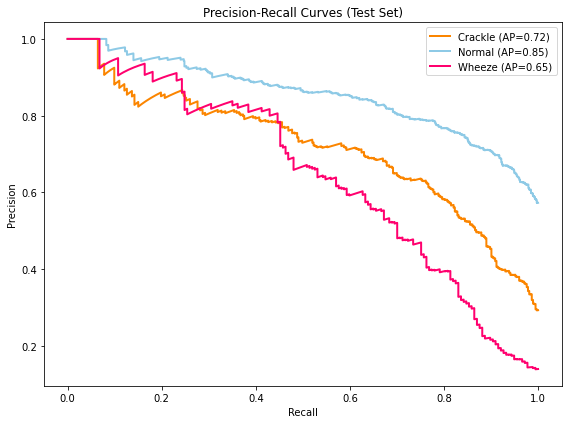

In [14]:
from statistical_models.evaluate import evaluate_model

xgb_metrics_df = evaluate_model(X_test, y_test, classes, xgb_model)

In [15]:
xgb_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.611260,0.895143,0.705882,0.848326,0.529767,0.753202
1,Normal,0.836763,0.625455,0.747549,0.742981,0.476163,0.731109
2,Wheeze,0.508475,0.954628,0.642857,0.923617,0.512187,0.731551


### **WITH DOMAIN ADAPTATION**

#### **SPECTRUM CORRECTION**

In [12]:
X_train = np.load("training_features_sc_2.npy")
y_train = np.load("training_labels_sc_2.npy")
X_test = np.load("test_features_sc_2.npy")
y_test = np.load("test_labels_sc_2.npy")

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
classes = le.classes_

scaler = MinMaxScaler(feature_range=(-1, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### **k-NN**


Fold 1


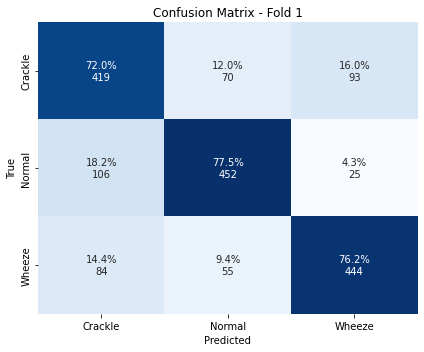

              precision    recall  f1-score   support

     Crackle       0.69      0.72      0.70       582
      Normal       0.78      0.78      0.78       583
      Wheeze       0.79      0.76      0.78       583

    accuracy                           0.75      1748
   macro avg       0.75      0.75      0.75      1748
weighted avg       0.75      0.75      0.75      1748


Fold 2


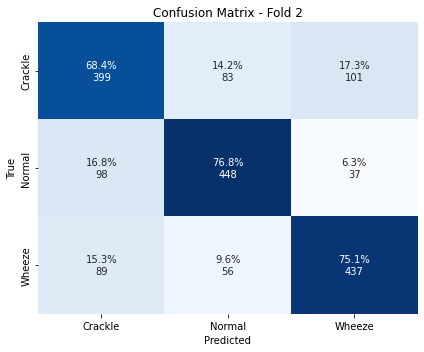

              precision    recall  f1-score   support

     Crackle       0.68      0.68      0.68       583
      Normal       0.76      0.77      0.77       583
      Wheeze       0.76      0.75      0.76       582

    accuracy                           0.73      1748
   macro avg       0.73      0.73      0.73      1748
weighted avg       0.73      0.73      0.73      1748


Fold 3


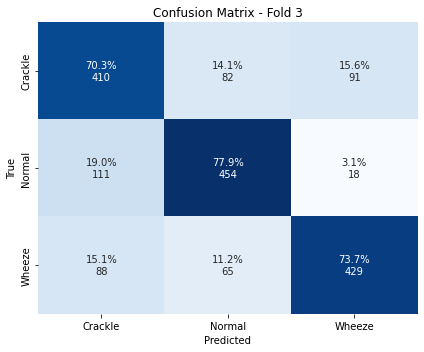

              precision    recall  f1-score   support

     Crackle       0.67      0.70      0.69       583
      Normal       0.76      0.78      0.77       583
      Wheeze       0.80      0.74      0.77       582

    accuracy                           0.74      1748
   macro avg       0.74      0.74      0.74      1748
weighted avg       0.74      0.74      0.74      1748


Fold 4


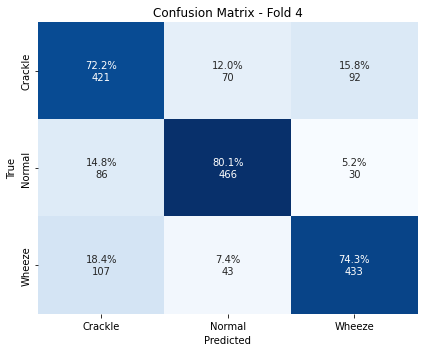

              precision    recall  f1-score   support

     Crackle       0.69      0.72      0.70       583
      Normal       0.80      0.80      0.80       582
      Wheeze       0.78      0.74      0.76       583

    accuracy                           0.76      1748
   macro avg       0.76      0.76      0.76      1748
weighted avg       0.76      0.76      0.76      1748


Fold 5


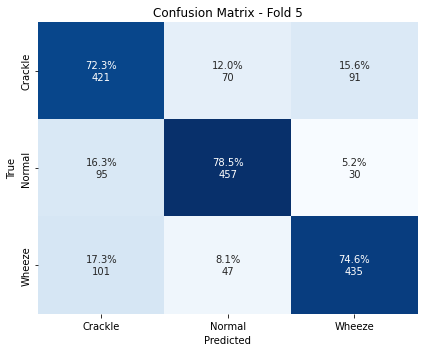

              precision    recall  f1-score   support

     Crackle       0.68      0.72      0.70       582
      Normal       0.80      0.79      0.79       582
      Wheeze       0.78      0.75      0.76       583

    accuracy                           0.75      1747
   macro avg       0.75      0.75      0.75      1747
weighted avg       0.75      0.75      0.75      1747



In [ ]:
from statistical_models.knn import *

# Training
knn_model = train(X_train, y_train, classes, n_neighbors=best_k)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.65      0.72      0.68       373
      Normal       0.79      0.80      0.80       729
      Wheeze       0.63      0.47      0.54       177

    accuracy                           0.73      1279
   macro avg       0.69      0.66      0.67      1279
weighted avg       0.73      0.73      0.73      1279



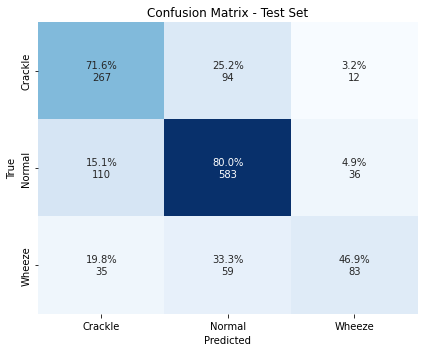

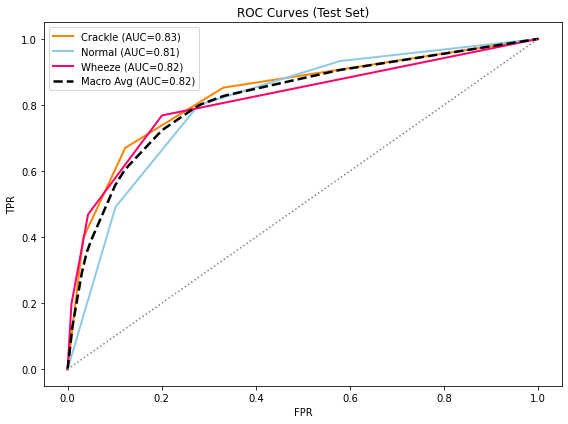

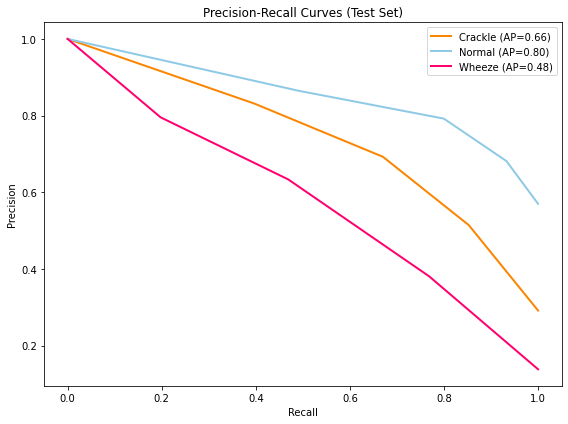

In [88]:
from statistical_models.evaluate import evaluate_model

knn_sc_metrics_df = evaluate_model(X_test, y_test, classes, knn_model)

In [72]:
knn_sc_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.715818,0.823400,0.625293,0.875587,0.519695,0.769609
1,Normal,0.776406,0.749091,0.803977,0.716522,0.522992,0.762748
2,Wheeze,0.559322,0.955535,0.668919,0.931034,0.555779,0.757429


#### **Non-Linear SVM (rbf kernel)**


Fold 1


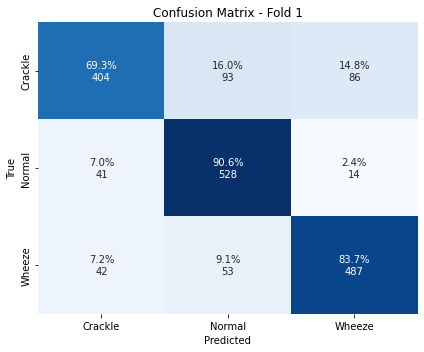

              precision    recall  f1-score   support

     Crackle       0.83      0.69      0.76       583
      Normal       0.78      0.91      0.84       583
      Wheeze       0.83      0.84      0.83       582

    accuracy                           0.81      1748
   macro avg       0.81      0.81      0.81      1748
weighted avg       0.81      0.81      0.81      1748


Fold 2


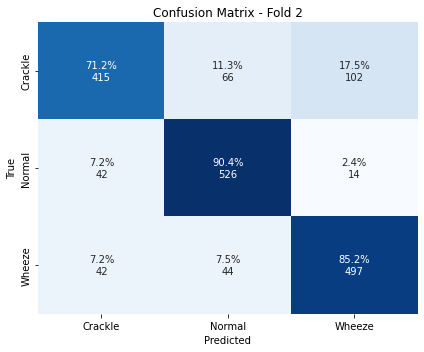

              precision    recall  f1-score   support

     Crackle       0.83      0.71      0.77       583
      Normal       0.83      0.90      0.86       582
      Wheeze       0.81      0.85      0.83       583

    accuracy                           0.82      1748
   macro avg       0.82      0.82      0.82      1748
weighted avg       0.82      0.82      0.82      1748


Fold 3


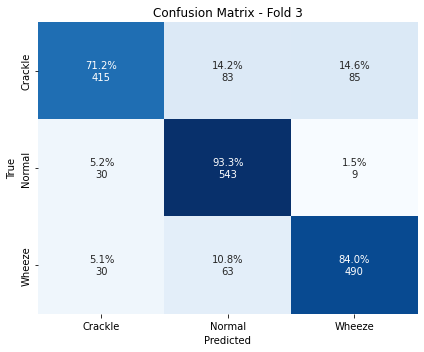

              precision    recall  f1-score   support

     Crackle       0.87      0.71      0.78       583
      Normal       0.79      0.93      0.85       582
      Wheeze       0.84      0.84      0.84       583

    accuracy                           0.83      1748
   macro avg       0.83      0.83      0.83      1748
weighted avg       0.83      0.83      0.83      1748


Fold 4


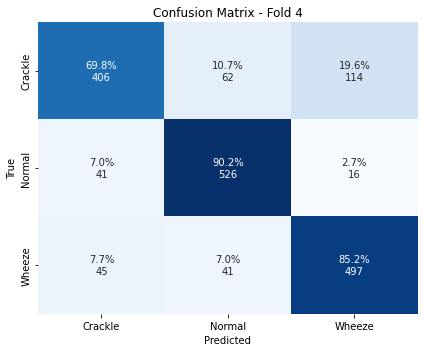

              precision    recall  f1-score   support

     Crackle       0.83      0.70      0.76       582
      Normal       0.84      0.90      0.87       583
      Wheeze       0.79      0.85      0.82       583

    accuracy                           0.82      1748
   macro avg       0.82      0.82      0.82      1748
weighted avg       0.82      0.82      0.82      1748


Fold 5


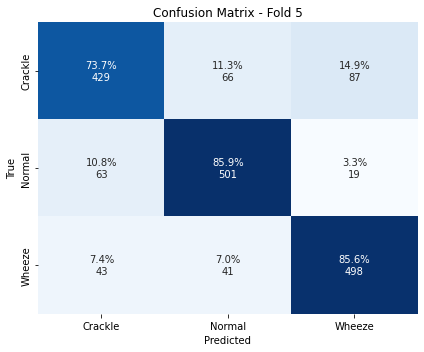

              precision    recall  f1-score   support

     Crackle       0.80      0.74      0.77       582
      Normal       0.82      0.86      0.84       583
      Wheeze       0.82      0.86      0.84       582

    accuracy                           0.82      1747
   macro avg       0.82      0.82      0.82      1747
weighted avg       0.82      0.82      0.82      1747



In [20]:
from statistical_models.non_linear_svm import *

svm_model = train(X_train, y_train, classes, best_params_svm)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.71      0.62      0.66       373
      Normal       0.76      0.85      0.80       729
      Wheeze       0.74      0.56      0.64       177

    accuracy                           0.74      1279
   macro avg       0.73      0.68      0.70      1279
weighted avg       0.74      0.74      0.74      1279



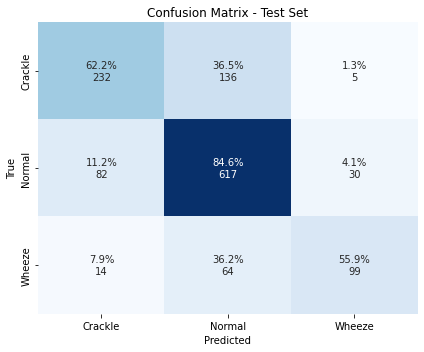

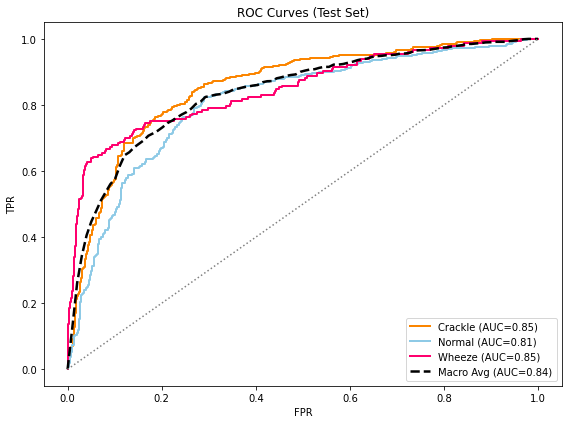

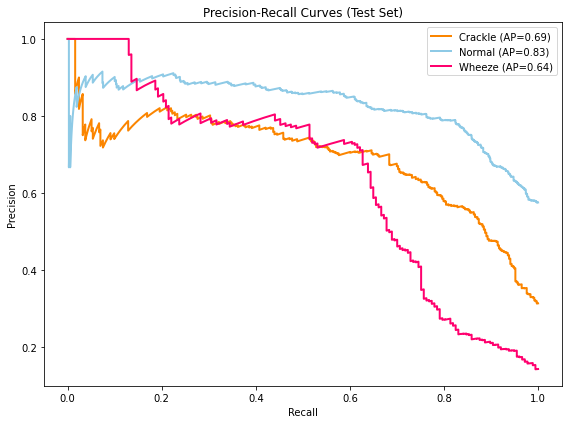

In [21]:
from statistical_models.evaluate import evaluate_model

svm_sc_metrics_df = evaluate_model(X_test, y_test, classes, svm_model)

In [26]:
svm_sc_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.621984,0.894040,0.707317,0.851735,0.537107,0.758012
1,Normal,0.846365,0.636364,0.755202,0.757576,0.497526,0.741364
2,Wheeze,0.559322,0.968240,0.738806,0.931878,0.594834,0.763781


#### **Random Forest**


Fold 1


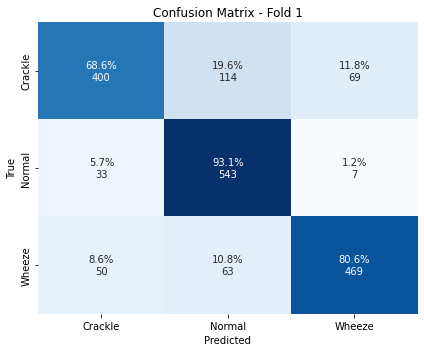

              precision    recall  f1-score   support

     Crackle       0.83      0.69      0.75       583
      Normal       0.75      0.93      0.83       583
      Wheeze       0.86      0.81      0.83       582

    accuracy                           0.81      1748
   macro avg       0.81      0.81      0.81      1748
weighted avg       0.81      0.81      0.81      1748


Fold 2


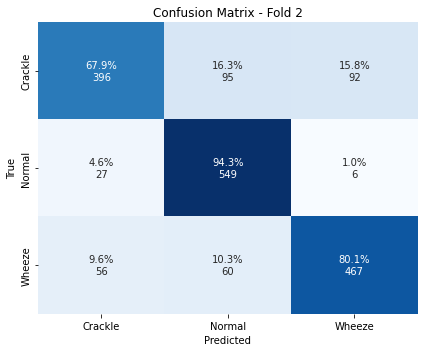

              precision    recall  f1-score   support

     Crackle       0.83      0.68      0.75       583
      Normal       0.78      0.94      0.85       582
      Wheeze       0.83      0.80      0.81       583

    accuracy                           0.81      1748
   macro avg       0.81      0.81      0.80      1748
weighted avg       0.81      0.81      0.80      1748


Fold 3


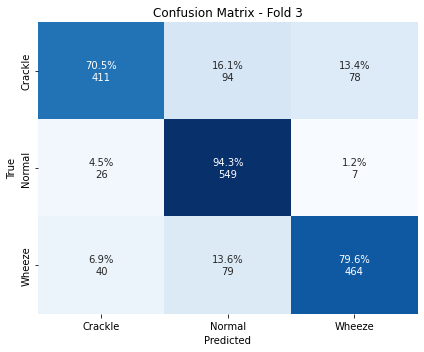

              precision    recall  f1-score   support

     Crackle       0.86      0.70      0.78       583
      Normal       0.76      0.94      0.84       582
      Wheeze       0.85      0.80      0.82       583

    accuracy                           0.81      1748
   macro avg       0.82      0.81      0.81      1748
weighted avg       0.82      0.81      0.81      1748


Fold 4


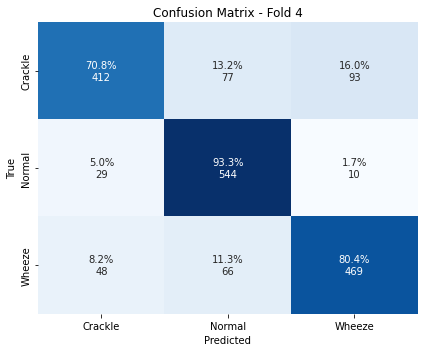

              precision    recall  f1-score   support

     Crackle       0.84      0.71      0.77       582
      Normal       0.79      0.93      0.86       583
      Wheeze       0.82      0.80      0.81       583

    accuracy                           0.82      1748
   macro avg       0.82      0.82      0.81      1748
weighted avg       0.82      0.82      0.81      1748


Fold 5


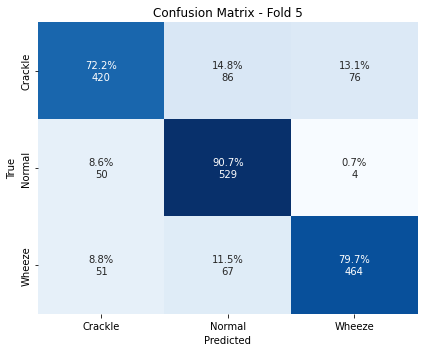

              precision    recall  f1-score   support

     Crackle       0.81      0.72      0.76       582
      Normal       0.78      0.91      0.84       583
      Wheeze       0.85      0.80      0.82       582

    accuracy                           0.81      1747
   macro avg       0.81      0.81      0.81      1747
weighted avg       0.81      0.81      0.81      1747



In [22]:
from statistical_models.random_forest import *

rf_model = train(X_train, y_train, classes, best_params_rf)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.71      0.55      0.62       373
      Normal       0.72      0.88      0.79       729
      Wheeze       0.76      0.44      0.55       177

    accuracy                           0.72      1279
   macro avg       0.73      0.62      0.66      1279
weighted avg       0.72      0.72      0.71      1279



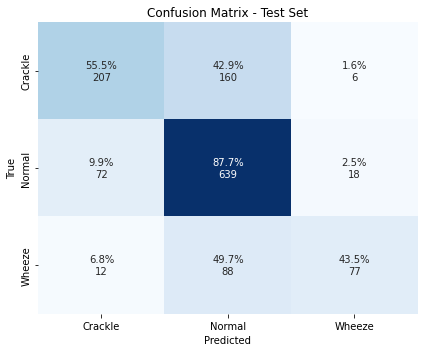

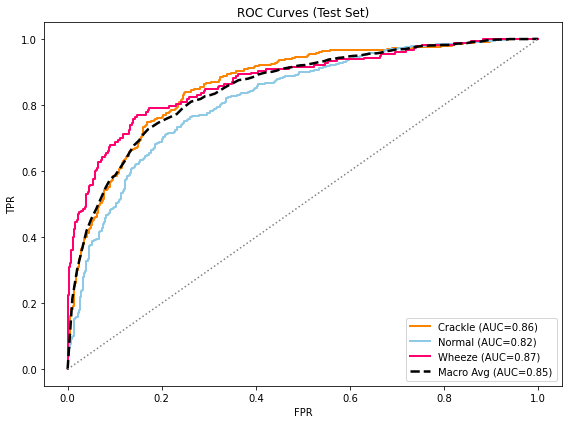

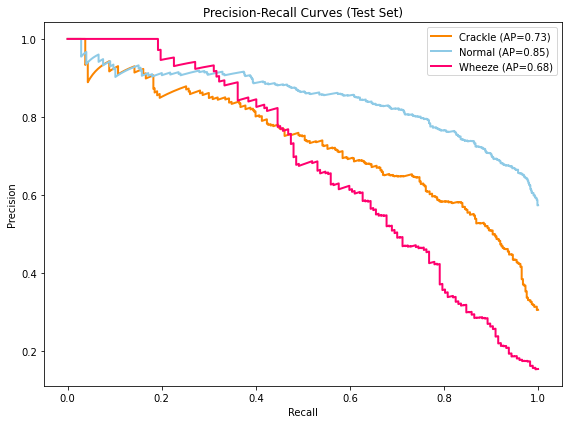

In [23]:
from statistical_models.evaluate import evaluate_model

rf_sc_metrics_df = evaluate_model(X_test, y_test, classes, rf_model)

In [25]:
rf_sc_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.554960,0.907285,0.711340,0.831984,0.501147,0.731122
1,Normal,0.876543,0.549091,0.720406,0.770408,0.457064,0.712817
2,Wheeze,0.435028,0.978221,0.762376,0.915110,0.529123,0.706625


#### **XGBoost**


Fold 1


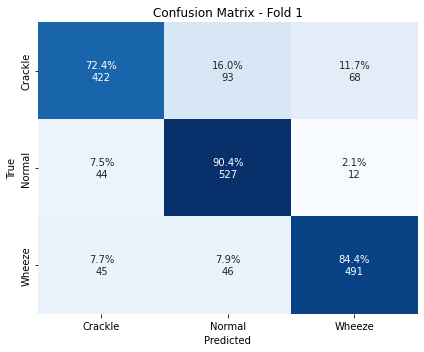

              precision    recall  f1-score   support

     Crackle       0.83      0.72      0.77       583
      Normal       0.79      0.90      0.84       583
      Wheeze       0.86      0.84      0.85       582

    accuracy                           0.82      1748
   macro avg       0.83      0.82      0.82      1748
weighted avg       0.83      0.82      0.82      1748


Fold 2


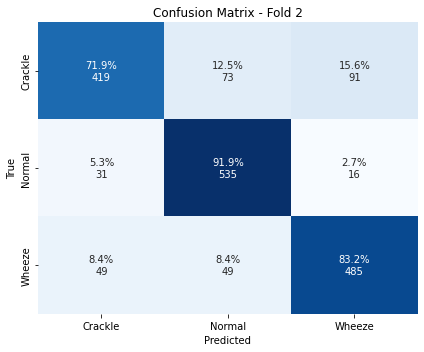

              precision    recall  f1-score   support

     Crackle       0.84      0.72      0.77       583
      Normal       0.81      0.92      0.86       582
      Wheeze       0.82      0.83      0.83       583

    accuracy                           0.82      1748
   macro avg       0.82      0.82      0.82      1748
weighted avg       0.82      0.82      0.82      1748


Fold 3


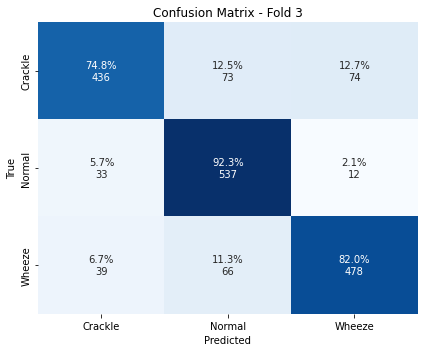

              precision    recall  f1-score   support

     Crackle       0.86      0.75      0.80       583
      Normal       0.79      0.92      0.85       582
      Wheeze       0.85      0.82      0.83       583

    accuracy                           0.83      1748
   macro avg       0.83      0.83      0.83      1748
weighted avg       0.83      0.83      0.83      1748


Fold 4


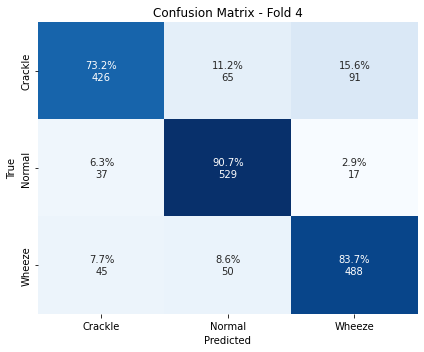

              precision    recall  f1-score   support

     Crackle       0.84      0.73      0.78       582
      Normal       0.82      0.91      0.86       583
      Wheeze       0.82      0.84      0.83       583

    accuracy                           0.83      1748
   macro avg       0.83      0.83      0.82      1748
weighted avg       0.83      0.83      0.82      1748


Fold 5


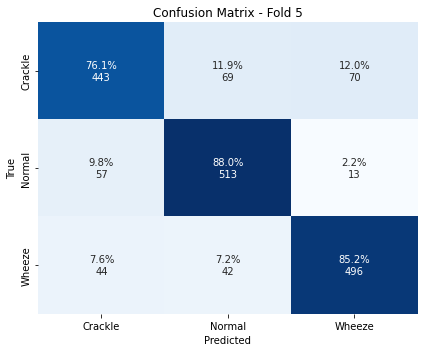

              precision    recall  f1-score   support

     Crackle       0.81      0.76      0.79       582
      Normal       0.82      0.88      0.85       583
      Wheeze       0.86      0.85      0.85       582

    accuracy                           0.83      1747
   macro avg       0.83      0.83      0.83      1747
weighted avg       0.83      0.83      0.83      1747



In [27]:
from statistical_models.xgboost import train

xgb_model = train(X_train, y_train, classes, best_params_xgb)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.72      0.60      0.65       373
      Normal       0.75      0.84      0.79       729
      Wheeze       0.69      0.56      0.62       177

    accuracy                           0.73      1279
   macro avg       0.72      0.67      0.69      1279
weighted avg       0.73      0.73      0.73      1279



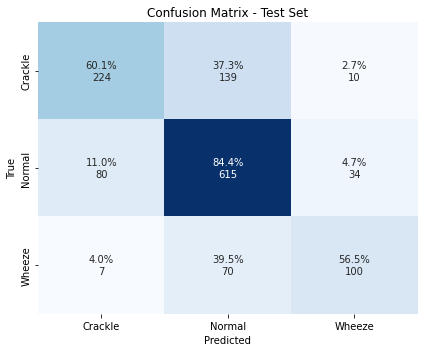

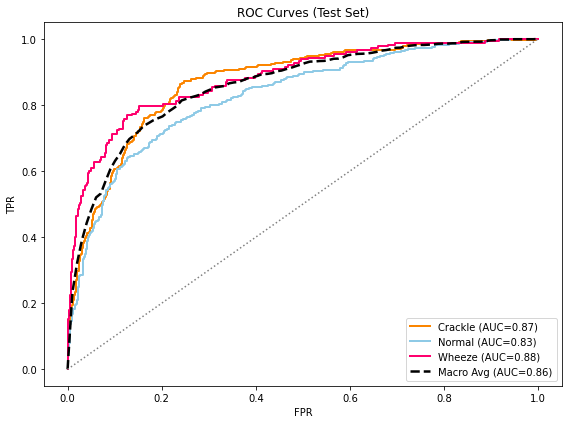

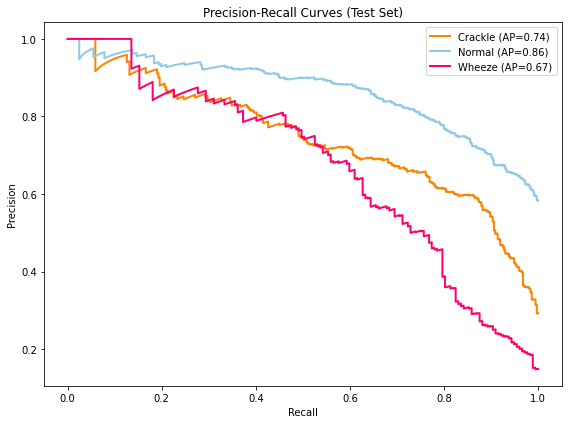

In [28]:
from statistical_models.evaluate import evaluate_model

xgb_sc_metrics_df = evaluate_model(X_test, y_test, classes, xgb_model)

In [29]:
xgb_sc_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.600536,0.903974,0.720257,0.846074,0.534528,0.752255
1,Normal,0.843621,0.620000,0.746359,0.749451,0.479446,0.731811
2,Wheeze,0.564972,0.960073,0.694444,0.932159,0.573580,0.762522


### **DANN**

In [ ]:
X_train = np.load("dann_embeddings_train.npy")
y_train = np.load("training_labels.npy")
X_test = np.load("dann_embeddings_test.npy")
y_test = np.load("test_labels.npy")

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
classes = le.classes_
 
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Fold 1


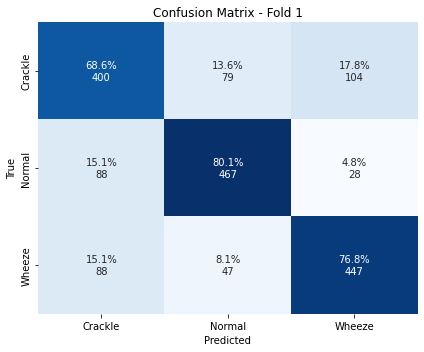

              precision    recall  f1-score   support

     Crackle       0.69      0.69      0.69       583
      Normal       0.79      0.80      0.79       583
      Wheeze       0.77      0.77      0.77       582

    accuracy                           0.75      1748
   macro avg       0.75      0.75      0.75      1748
weighted avg       0.75      0.75      0.75      1748


Fold 2


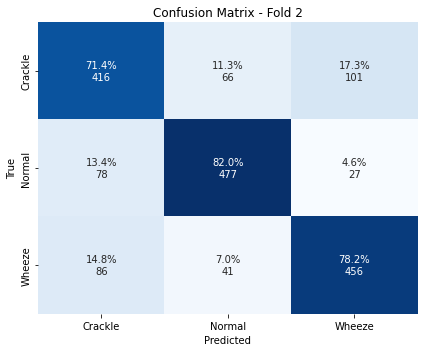

              precision    recall  f1-score   support

     Crackle       0.72      0.71      0.72       583
      Normal       0.82      0.82      0.82       582
      Wheeze       0.78      0.78      0.78       583

    accuracy                           0.77      1748
   macro avg       0.77      0.77      0.77      1748
weighted avg       0.77      0.77      0.77      1748


Fold 3


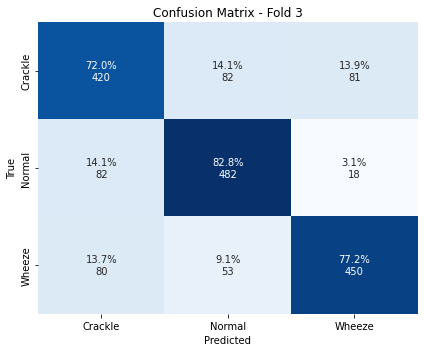

              precision    recall  f1-score   support

     Crackle       0.72      0.72      0.72       583
      Normal       0.78      0.83      0.80       582
      Wheeze       0.82      0.77      0.80       583

    accuracy                           0.77      1748
   macro avg       0.77      0.77      0.77      1748
weighted avg       0.77      0.77      0.77      1748


Fold 4


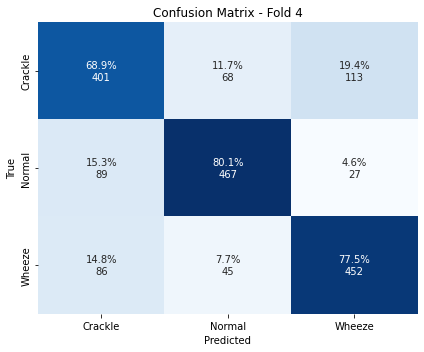

              precision    recall  f1-score   support

     Crackle       0.70      0.69      0.69       582
      Normal       0.81      0.80      0.80       583
      Wheeze       0.76      0.78      0.77       583

    accuracy                           0.76      1748
   macro avg       0.75      0.76      0.76      1748
weighted avg       0.75      0.76      0.76      1748


Fold 5


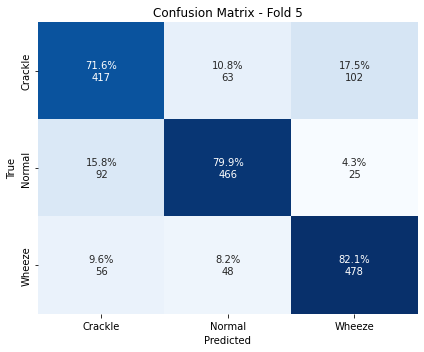

              precision    recall  f1-score   support

     Crackle       0.74      0.72      0.73       582
      Normal       0.81      0.80      0.80       583
      Wheeze       0.79      0.82      0.81       582

    accuracy                           0.78      1747
   macro avg       0.78      0.78      0.78      1747
weighted avg       0.78      0.78      0.78      1747



In [ ]:
from statistical_models.knn import *

knn_model = train(X_train, y_train, classes, n_neighbors=best_k)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.66      0.71      0.68       373
      Normal       0.80      0.80      0.80       729
      Wheeze       0.73      0.59      0.66       177

    accuracy                           0.75      1279
   macro avg       0.73      0.70      0.71      1279
weighted avg       0.75      0.75      0.75      1279



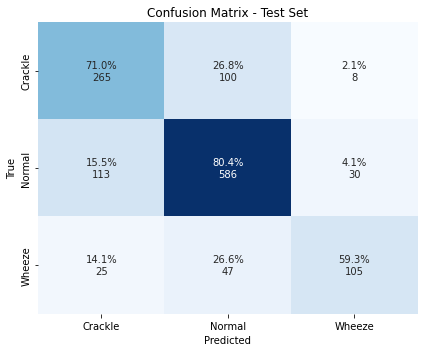

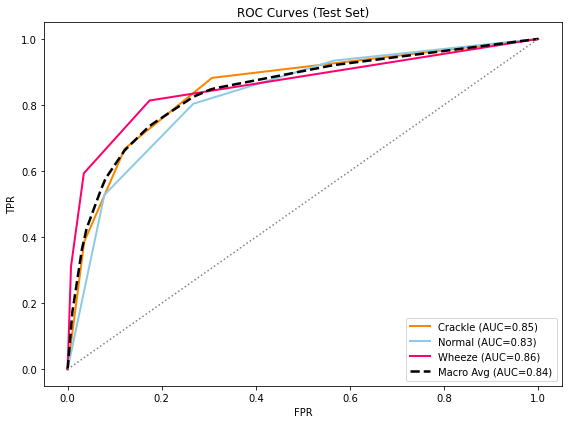

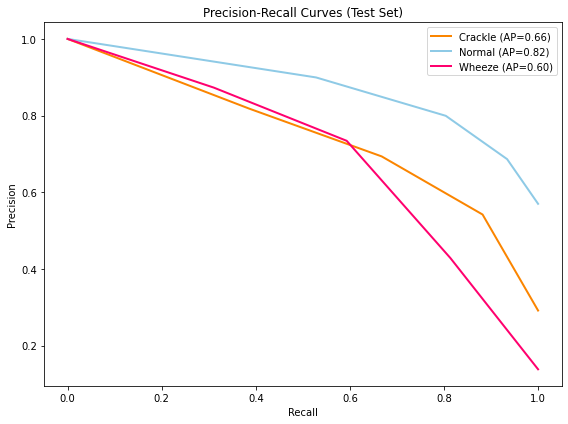

In [98]:
knn_dann_metrics_df = evaluate_model(X_test, y_test, classes, knn_model)

In [99]:
knn_dann_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.710456,0.847682,0.657568,0.876712,0.546079,0.779069
1,Normal,0.803841,0.732727,0.799454,0.738095,0.537059,0.768284
2,Wheeze,0.593220,0.965517,0.734266,0.936620,0.612249,0.779369


#### **Non-Linear SVM (rbf kernel)**


Fold 1


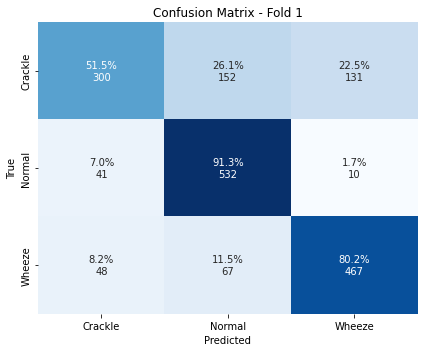

              precision    recall  f1-score   support

     Crackle       0.77      0.51      0.62       583
      Normal       0.71      0.91      0.80       583
      Wheeze       0.77      0.80      0.78       582

    accuracy                           0.74      1748
   macro avg       0.75      0.74      0.73      1748
weighted avg       0.75      0.74      0.73      1748


Fold 2


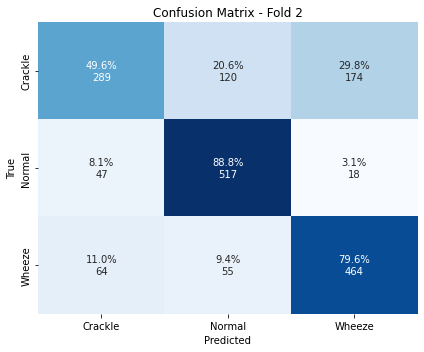

              precision    recall  f1-score   support

     Crackle       0.72      0.50      0.59       583
      Normal       0.75      0.89      0.81       582
      Wheeze       0.71      0.80      0.75       583

    accuracy                           0.73      1748
   macro avg       0.73      0.73      0.72      1748
weighted avg       0.73      0.73      0.72      1748


Fold 3


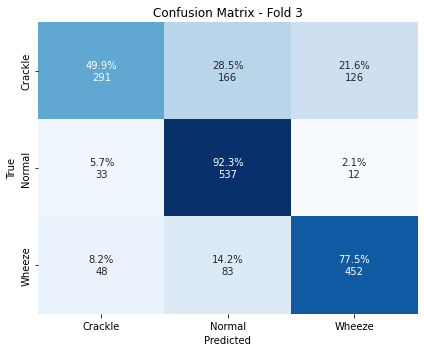

              precision    recall  f1-score   support

     Crackle       0.78      0.50      0.61       583
      Normal       0.68      0.92      0.79       582
      Wheeze       0.77      0.78      0.77       583

    accuracy                           0.73      1748
   macro avg       0.74      0.73      0.72      1748
weighted avg       0.74      0.73      0.72      1748


Fold 4


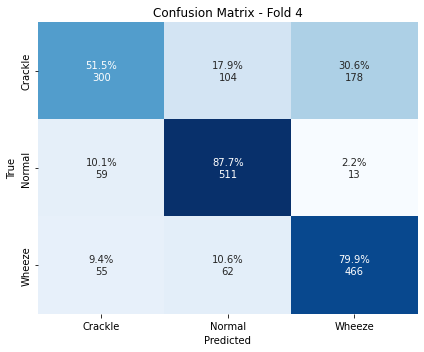

              precision    recall  f1-score   support

     Crackle       0.72      0.52      0.60       582
      Normal       0.75      0.88      0.81       583
      Wheeze       0.71      0.80      0.75       583

    accuracy                           0.73      1748
   macro avg       0.73      0.73      0.72      1748
weighted avg       0.73      0.73      0.72      1748


Fold 5


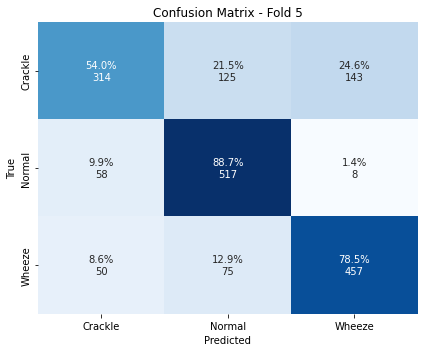

              precision    recall  f1-score   support

     Crackle       0.74      0.54      0.63       582
      Normal       0.72      0.89      0.80       583
      Wheeze       0.75      0.79      0.77       582

    accuracy                           0.74      1747
   macro avg       0.74      0.74      0.73      1747
weighted avg       0.74      0.74      0.73      1747



In [ ]:
from statistical_models.non_linear_svm import *

svm_model = train(X_train, y_train, classes, best_params_svm)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.67      0.53      0.59       373
      Normal       0.71      0.85      0.77       729
      Wheeze       0.68      0.40      0.50       177

    accuracy                           0.70      1279
   macro avg       0.69      0.59      0.62      1279
weighted avg       0.69      0.70      0.68      1279



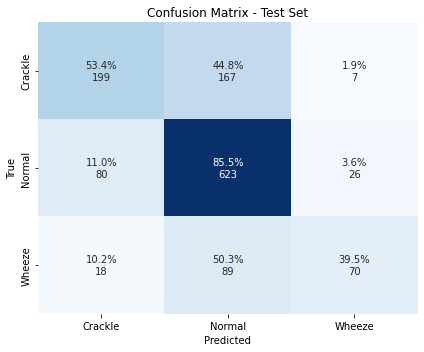

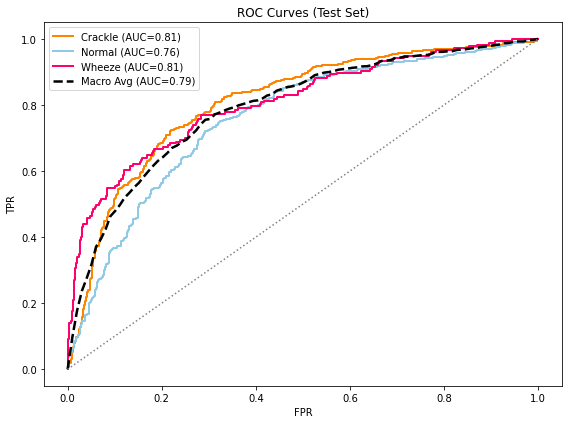

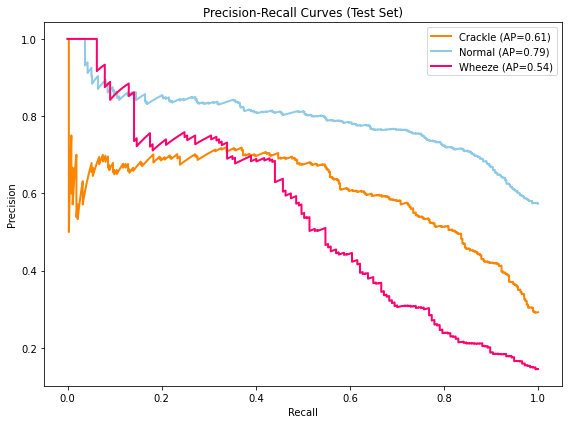

In [101]:
svm_dann_metrics_df = evaluate_model(X_test, y_test, classes, svm_model)

In [102]:
svm_dann_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.533512,0.891832,0.670034,0.822811,0.457852,0.712672
1,Normal,0.854595,0.534545,0.708760,0.735000,0.415554,0.694570
2,Wheeze,0.395480,0.970054,0.679612,0.909014,0.463857,0.682767


#### **Random Forest**


Fold 1


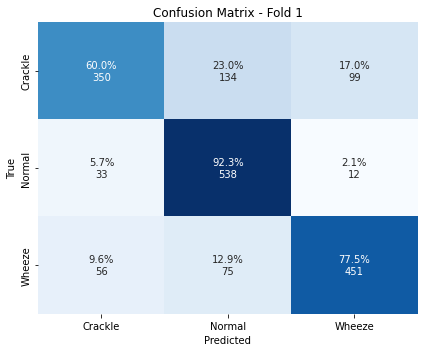

              precision    recall  f1-score   support

     Crackle       0.80      0.60      0.68       583
      Normal       0.72      0.92      0.81       583
      Wheeze       0.80      0.77      0.79       582

    accuracy                           0.77      1748
   macro avg       0.77      0.77      0.76      1748
weighted avg       0.77      0.77      0.76      1748


Fold 2


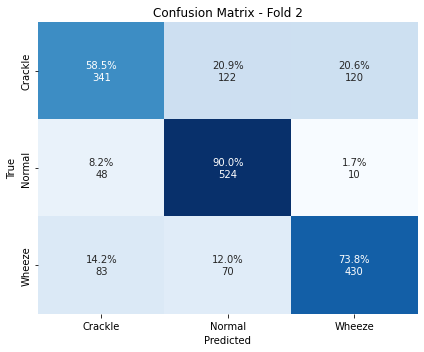

              precision    recall  f1-score   support

     Crackle       0.72      0.58      0.65       583
      Normal       0.73      0.90      0.81       582
      Wheeze       0.77      0.74      0.75       583

    accuracy                           0.74      1748
   macro avg       0.74      0.74      0.74      1748
weighted avg       0.74      0.74      0.74      1748


Fold 3


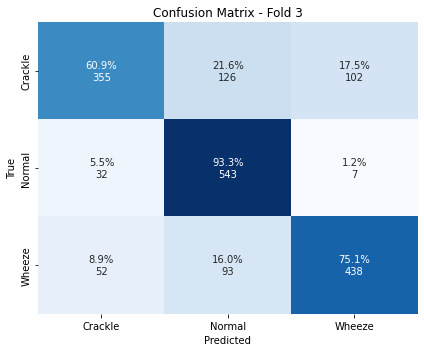

              precision    recall  f1-score   support

     Crackle       0.81      0.61      0.69       583
      Normal       0.71      0.93      0.81       582
      Wheeze       0.80      0.75      0.78       583

    accuracy                           0.76      1748
   macro avg       0.77      0.76      0.76      1748
weighted avg       0.77      0.76      0.76      1748


Fold 4


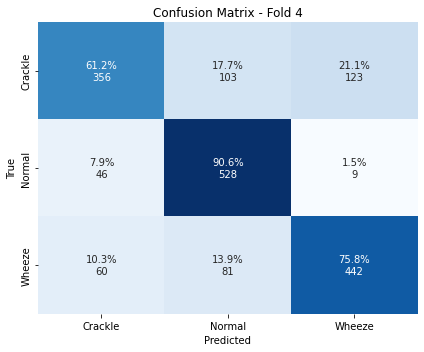

              precision    recall  f1-score   support

     Crackle       0.77      0.61      0.68       582
      Normal       0.74      0.91      0.82       583
      Wheeze       0.77      0.76      0.76       583

    accuracy                           0.76      1748
   macro avg       0.76      0.76      0.75      1748
weighted avg       0.76      0.76      0.75      1748


Fold 5


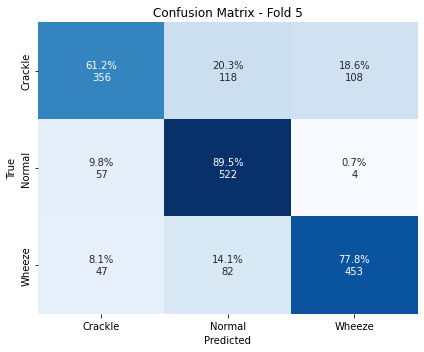

              precision    recall  f1-score   support

     Crackle       0.77      0.61      0.68       582
      Normal       0.72      0.90      0.80       583
      Wheeze       0.80      0.78      0.79       582

    accuracy                           0.76      1747
   macro avg       0.77      0.76      0.76      1747
weighted avg       0.77      0.76      0.76      1747



In [ ]:
from statistical_models.random_forest import *

rf_model = train(X_train, y_train, classes, best_params_rf)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.70      0.53      0.60       373
      Normal       0.71      0.89      0.79       729
      Wheeze       0.77      0.34      0.47       177

    accuracy                           0.71      1279
   macro avg       0.72      0.58      0.62      1279
weighted avg       0.71      0.71      0.69      1279



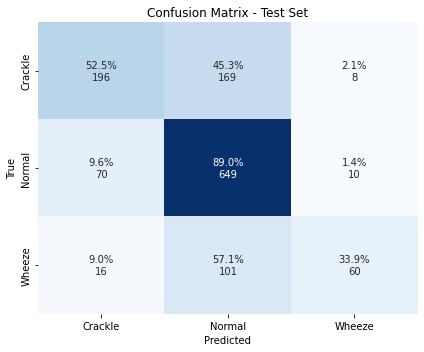

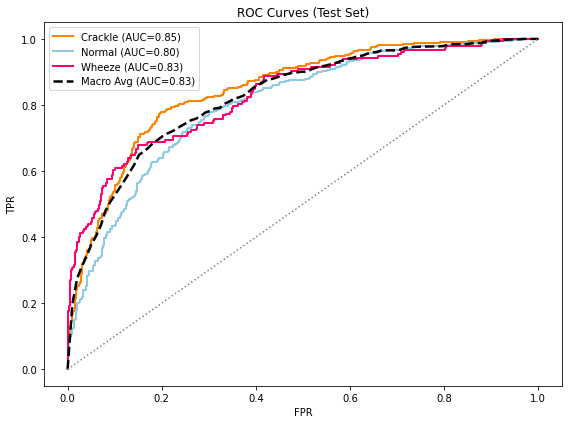

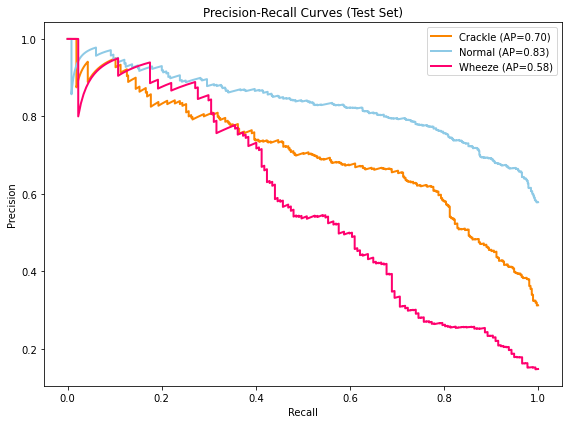

In [104]:
rf_dann_metrics_df = evaluate_model(X_test, y_test, classes, rf_model)

In [105]:
rf_dann_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.525469,0.905077,0.695035,0.822467,0.472026,0.715273
1,Normal,0.890261,0.509091,0.706202,0.777778,0.439634,0.699676
2,Wheeze,0.338983,0.983666,0.769231,0.902581,0.465574,0.661325


#### **XGBoost**


Fold 1


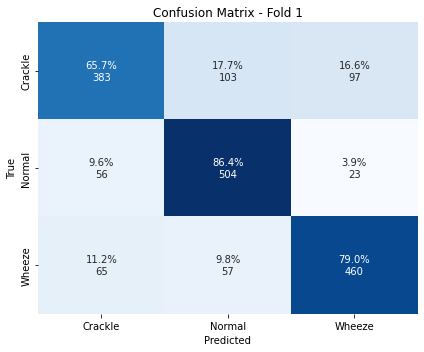

              precision    recall  f1-score   support

     Crackle       0.76      0.66      0.70       583
      Normal       0.76      0.86      0.81       583
      Wheeze       0.79      0.79      0.79       582

    accuracy                           0.77      1748
   macro avg       0.77      0.77      0.77      1748
weighted avg       0.77      0.77      0.77      1748


Fold 2


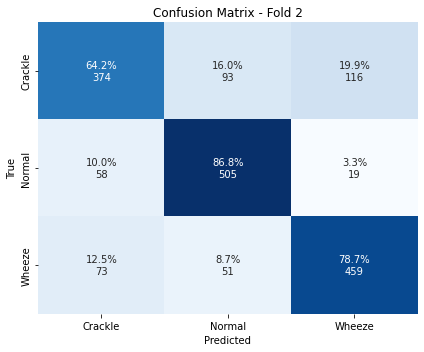

              precision    recall  f1-score   support

     Crackle       0.74      0.64      0.69       583
      Normal       0.78      0.87      0.82       582
      Wheeze       0.77      0.79      0.78       583

    accuracy                           0.77      1748
   macro avg       0.76      0.77      0.76      1748
weighted avg       0.76      0.77      0.76      1748


Fold 3


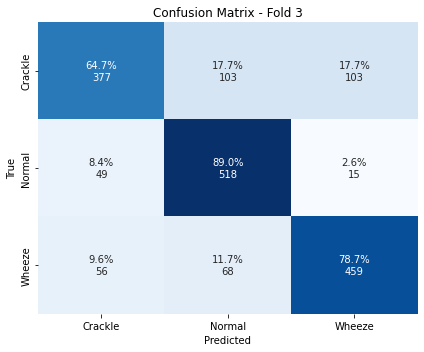

              precision    recall  f1-score   support

     Crackle       0.78      0.65      0.71       583
      Normal       0.75      0.89      0.82       582
      Wheeze       0.80      0.79      0.79       583

    accuracy                           0.77      1748
   macro avg       0.78      0.77      0.77      1748
weighted avg       0.78      0.77      0.77      1748


Fold 4


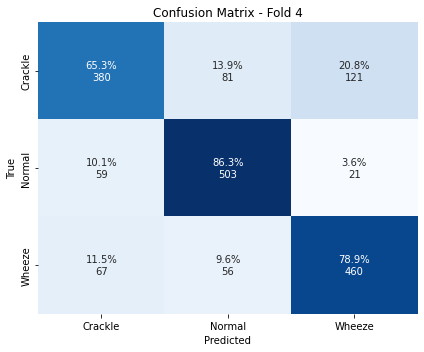

              precision    recall  f1-score   support

     Crackle       0.75      0.65      0.70       582
      Normal       0.79      0.86      0.82       583
      Wheeze       0.76      0.79      0.78       583

    accuracy                           0.77      1748
   macro avg       0.77      0.77      0.77      1748
weighted avg       0.77      0.77      0.77      1748


Fold 5


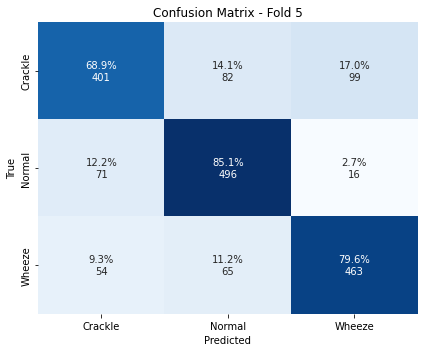

              precision    recall  f1-score   support

     Crackle       0.76      0.69      0.72       582
      Normal       0.77      0.85      0.81       583
      Wheeze       0.80      0.80      0.80       582

    accuracy                           0.78      1747
   macro avg       0.78      0.78      0.78      1747
weighted avg       0.78      0.78      0.78      1747



In [ ]:
from statistical_models.xgboost import *

xgb_model = train(X_train, y_train, classes, best_params_xgb)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.70      0.64      0.67       373
      Normal       0.76      0.85      0.80       729
      Wheeze       0.71      0.51      0.59       177

    accuracy                           0.74      1279
   macro avg       0.73      0.67      0.69      1279
weighted avg       0.74      0.74      0.74      1279



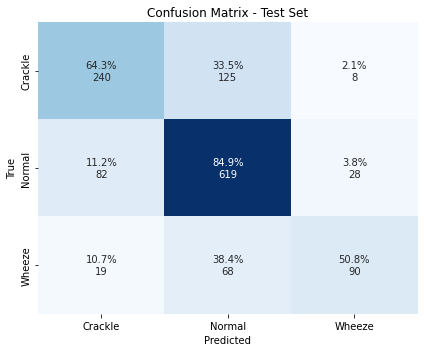

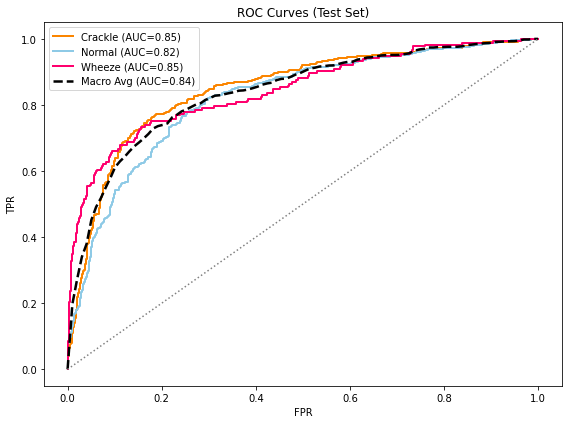

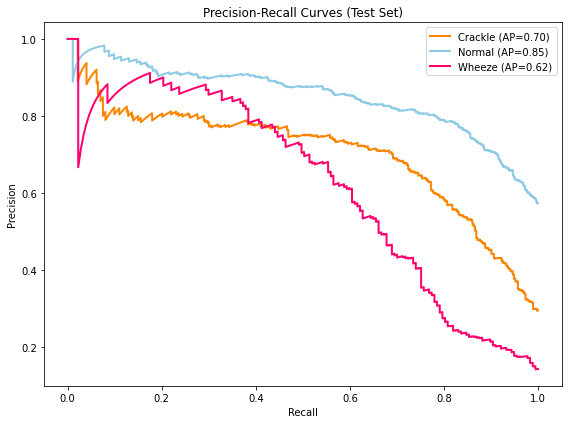

In [107]:
xgb_dann_metrics_df = evaluate_model(X_test, y_test, classes, xgb_model)

In [108]:
xgb_dann_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.643432,0.888521,0.703812,0.858209,0.546780,0.765976
1,Normal,0.849108,0.649091,0.762315,0.764454,0.512285,0.749100
2,Wheeze,0.508475,0.967332,0.714286,0.924545,0.551325,0.737903


### **CDAN**

In [ ]:
X_train = np.load("cdan_embeddings_train.npy")
y_train = np.load("training_labels.npy")
X_test = np.load("cdan_embeddings_test.npy")
y_test = np.load("test_labels.npy")

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
classes = le.classes_

# Apply MinMax Scaling 
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### **k-NN**


Fold 1


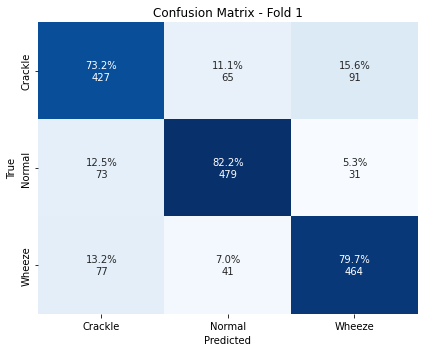

              precision    recall  f1-score   support

     Crackle       0.74      0.73      0.74       583
      Normal       0.82      0.82      0.82       583
      Wheeze       0.79      0.80      0.79       582

    accuracy                           0.78      1748
   macro avg       0.78      0.78      0.78      1748
weighted avg       0.78      0.78      0.78      1748


Fold 2


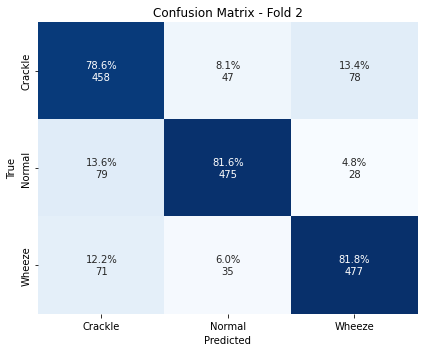

              precision    recall  f1-score   support

     Crackle       0.75      0.79      0.77       583
      Normal       0.85      0.82      0.83       582
      Wheeze       0.82      0.82      0.82       583

    accuracy                           0.81      1748
   macro avg       0.81      0.81      0.81      1748
weighted avg       0.81      0.81      0.81      1748


Fold 3


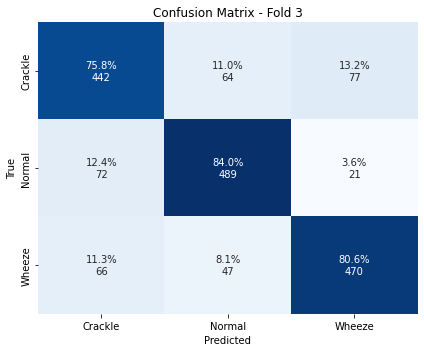

              precision    recall  f1-score   support

     Crackle       0.76      0.76      0.76       583
      Normal       0.81      0.84      0.83       582
      Wheeze       0.83      0.81      0.82       583

    accuracy                           0.80      1748
   macro avg       0.80      0.80      0.80      1748
weighted avg       0.80      0.80      0.80      1748


Fold 4


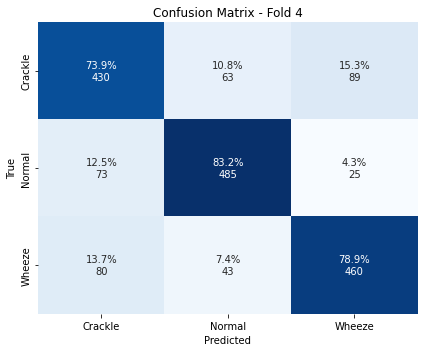

              precision    recall  f1-score   support

     Crackle       0.74      0.74      0.74       582
      Normal       0.82      0.83      0.83       583
      Wheeze       0.80      0.79      0.80       583

    accuracy                           0.79      1748
   macro avg       0.79      0.79      0.79      1748
weighted avg       0.79      0.79      0.79      1748


Fold 5


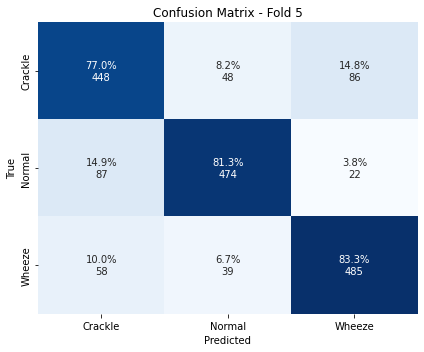

              precision    recall  f1-score   support

     Crackle       0.76      0.77      0.76       582
      Normal       0.84      0.81      0.83       583
      Wheeze       0.82      0.83      0.83       582

    accuracy                           0.81      1747
   macro avg       0.81      0.81      0.81      1747
weighted avg       0.81      0.81      0.81      1747



In [ ]:
from statistical_models.knn import *

knn_model = train(X_train, y_train, classes, n_neighbors=best_k)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.69      0.75      0.72       373
      Normal       0.82      0.81      0.82       729
      Wheeze       0.74      0.61      0.67       177

    accuracy                           0.77      1279
   macro avg       0.75      0.73      0.73      1279
weighted avg       0.77      0.77      0.77      1279



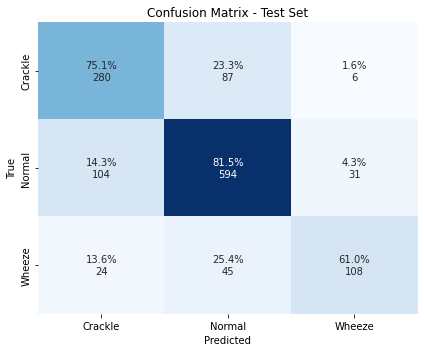

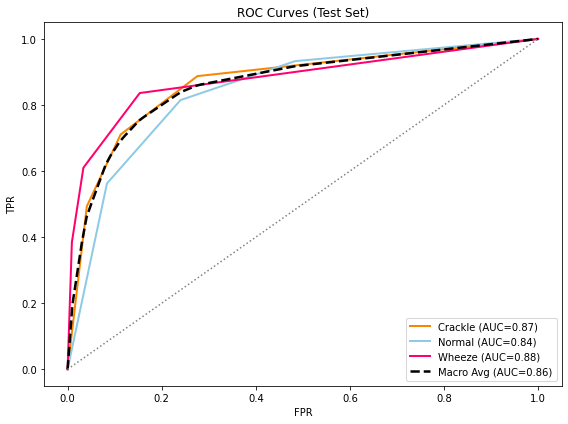

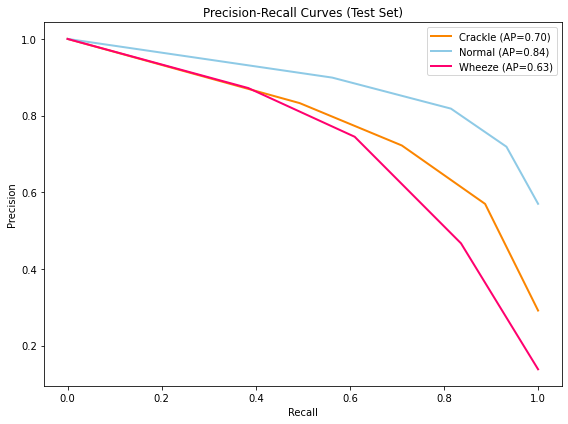

In [ ]:
knn_cdan_metrics_df = evaluate_model(X_test, y_test, classes, knn_model)

In [ ]:
knn_cdan_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.750670,0.858720,0.686275,0.893226,0.594257,0.804695
1,Normal,0.814815,0.760000,0.818182,0.755877,0.574437,0.787407
2,Wheeze,0.610169,0.966425,0.744828,0.939153,0.627996,0.788297


#### **Non-Linear SVM (rbf kernel)**


Fold 1


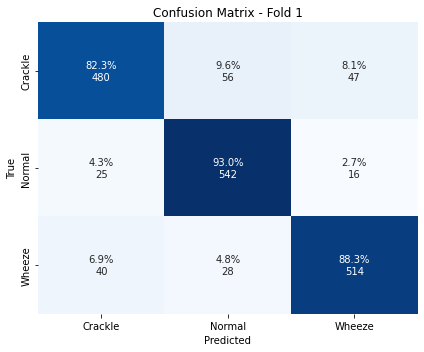

              precision    recall  f1-score   support

     Crackle       0.88      0.82      0.85       583
      Normal       0.87      0.93      0.90       583
      Wheeze       0.89      0.88      0.89       582

    accuracy                           0.88      1748
   macro avg       0.88      0.88      0.88      1748
weighted avg       0.88      0.88      0.88      1748


Fold 2


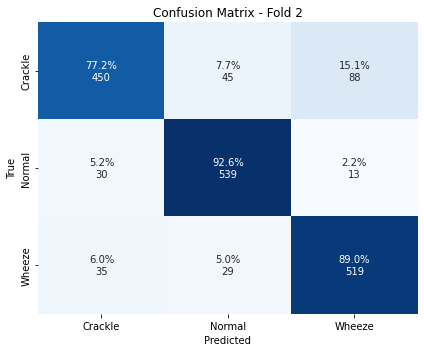

              precision    recall  f1-score   support

     Crackle       0.87      0.77      0.82       583
      Normal       0.88      0.93      0.90       582
      Wheeze       0.84      0.89      0.86       583

    accuracy                           0.86      1748
   macro avg       0.86      0.86      0.86      1748
weighted avg       0.86      0.86      0.86      1748


Fold 3


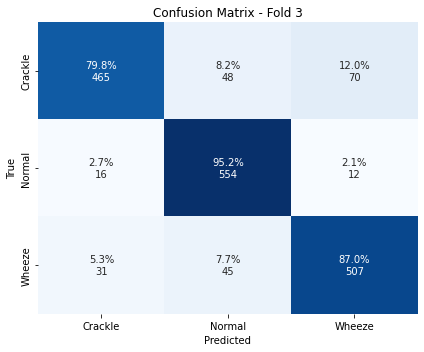

              precision    recall  f1-score   support

     Crackle       0.91      0.80      0.85       583
      Normal       0.86      0.95      0.90       582
      Wheeze       0.86      0.87      0.87       583

    accuracy                           0.87      1748
   macro avg       0.88      0.87      0.87      1748
weighted avg       0.88      0.87      0.87      1748


Fold 4


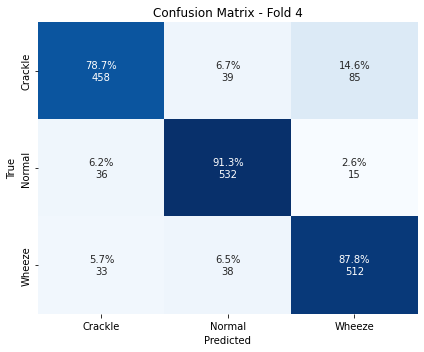

              precision    recall  f1-score   support

     Crackle       0.87      0.79      0.83       582
      Normal       0.87      0.91      0.89       583
      Wheeze       0.84      0.88      0.86       583

    accuracy                           0.86      1748
   macro avg       0.86      0.86      0.86      1748
weighted avg       0.86      0.86      0.86      1748


Fold 5


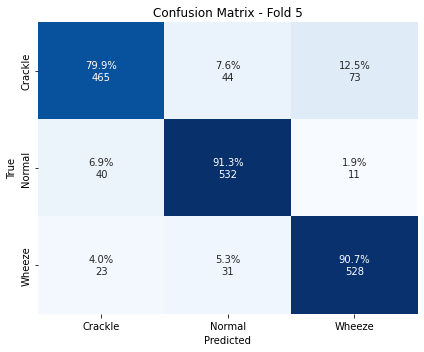

              precision    recall  f1-score   support

     Crackle       0.88      0.80      0.84       582
      Normal       0.88      0.91      0.89       583
      Wheeze       0.86      0.91      0.88       582

    accuracy                           0.87      1747
   macro avg       0.87      0.87      0.87      1747
weighted avg       0.87      0.87      0.87      1747



In [ ]:
from statistical_models.non_linear_svm import *

svm_model = train(X_train, y_train, classes, best_params_svm)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.73      0.71      0.72       373
      Normal       0.80      0.83      0.82       729
      Wheeze       0.71      0.65      0.68       177

    accuracy                           0.77      1279
   macro avg       0.75      0.73      0.74      1279
weighted avg       0.77      0.77      0.77      1279



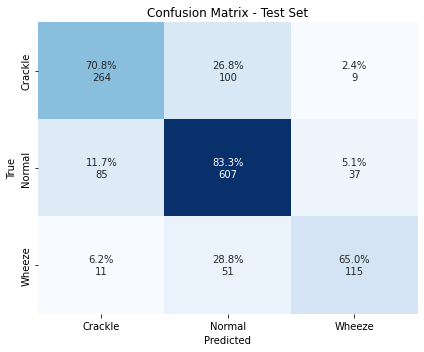

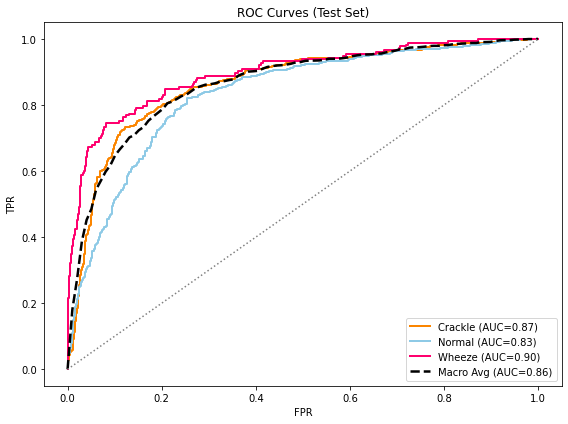

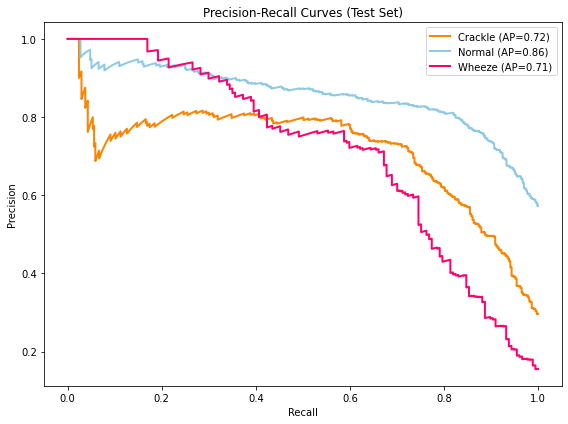

In [21]:
svm_cdan_metrics_df = evaluate_model(X_test, y_test, classes, svm_model)

In [22]:
svm_cdan_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.707775,0.894040,0.733333,0.881393,0.608236,0.800907
1,Normal,0.832647,0.725455,0.800792,0.765835,0.562348,0.779051
2,Wheeze,0.649718,0.958258,0.714286,0.944544,0.632892,0.803988


#### **Random Forest**


Fold 1


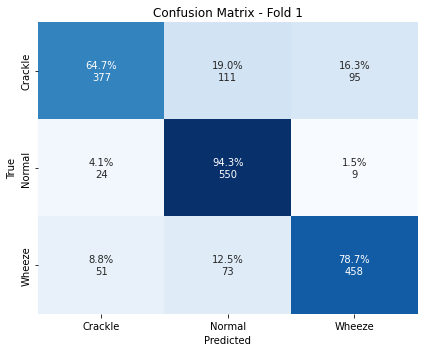

              precision    recall  f1-score   support

     Crackle       0.83      0.65      0.73       583
      Normal       0.75      0.94      0.84       583
      Wheeze       0.81      0.79      0.80       582

    accuracy                           0.79      1748
   macro avg       0.80      0.79      0.79      1748
weighted avg       0.80      0.79      0.79      1748


Fold 2


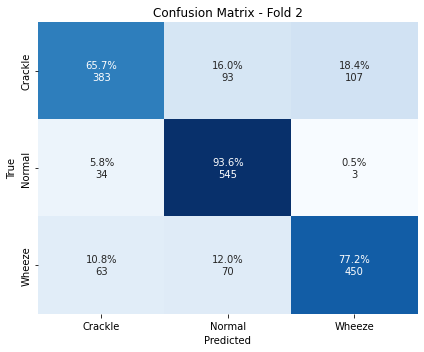

              precision    recall  f1-score   support

     Crackle       0.80      0.66      0.72       583
      Normal       0.77      0.94      0.84       582
      Wheeze       0.80      0.77      0.79       583

    accuracy                           0.79      1748
   macro avg       0.79      0.79      0.78      1748
weighted avg       0.79      0.79      0.78      1748


Fold 3


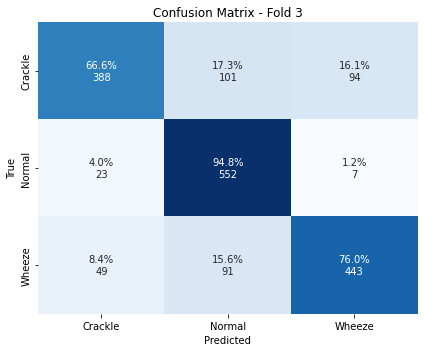

              precision    recall  f1-score   support

     Crackle       0.84      0.67      0.74       583
      Normal       0.74      0.95      0.83       582
      Wheeze       0.81      0.76      0.79       583

    accuracy                           0.79      1748
   macro avg       0.80      0.79      0.79      1748
weighted avg       0.80      0.79      0.79      1748


Fold 4


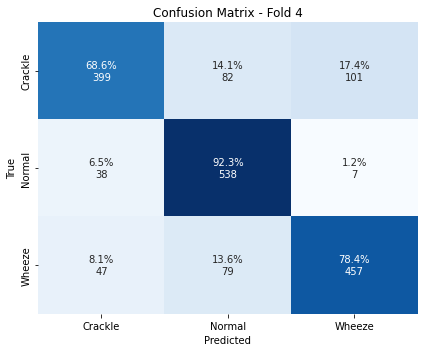

              precision    recall  f1-score   support

     Crackle       0.82      0.69      0.75       582
      Normal       0.77      0.92      0.84       583
      Wheeze       0.81      0.78      0.80       583

    accuracy                           0.80      1748
   macro avg       0.80      0.80      0.79      1748
weighted avg       0.80      0.80      0.79      1748


Fold 5


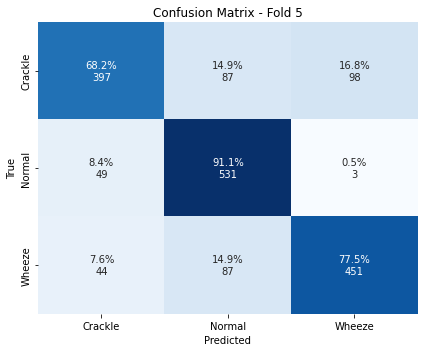

              precision    recall  f1-score   support

     Crackle       0.81      0.68      0.74       582
      Normal       0.75      0.91      0.82       583
      Wheeze       0.82      0.77      0.80       582

    accuracy                           0.79      1747
   macro avg       0.79      0.79      0.79      1747
weighted avg       0.79      0.79      0.79      1747



In [ ]:
from statistical_models.random_forest import *

rf_model = train(X_train, y_train, classes, best_params_rf)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.73      0.59      0.65       373
      Normal       0.72      0.90      0.80       729
      Wheeze       0.94      0.35      0.51       177

    accuracy                           0.74      1279
   macro avg       0.80      0.62      0.66      1279
weighted avg       0.75      0.74      0.72      1279



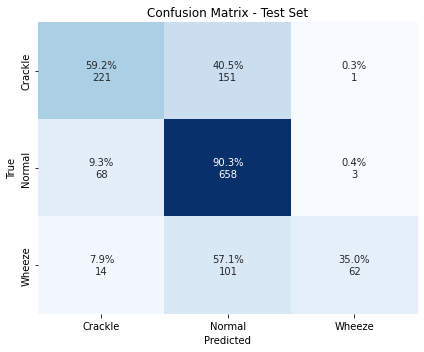

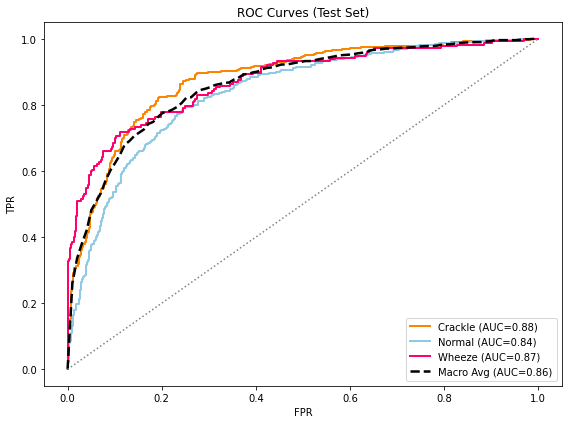

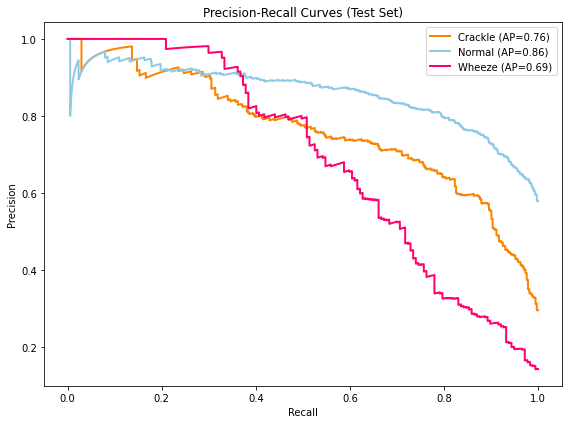

In [24]:
rf_cdan_metrics_df = evaluate_model(X_test, y_test, classes, rf_model)

In [25]:
rf_cdan_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.592493,0.909492,0.729373,0.844262,0.536616,0.750993
1,Normal,0.902606,0.541818,0.723077,0.807588,0.485634,0.722212
2,Wheeze,0.350282,0.996370,0.939394,0.905194,0.541090,0.673326


#### **XGBoost**


Fold 1


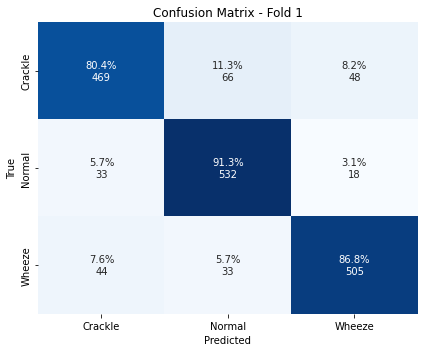

              precision    recall  f1-score   support

     Crackle       0.86      0.80      0.83       583
      Normal       0.84      0.91      0.88       583
      Wheeze       0.88      0.87      0.88       582

    accuracy                           0.86      1748
   macro avg       0.86      0.86      0.86      1748
weighted avg       0.86      0.86      0.86      1748


Fold 2


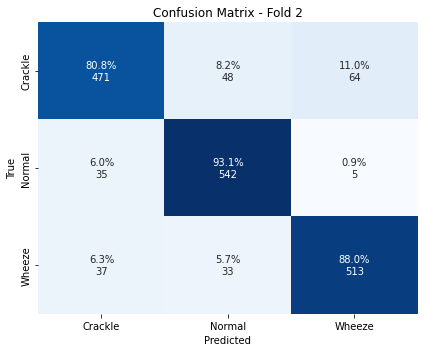

              precision    recall  f1-score   support

     Crackle       0.87      0.81      0.84       583
      Normal       0.87      0.93      0.90       582
      Wheeze       0.88      0.88      0.88       583

    accuracy                           0.87      1748
   macro avg       0.87      0.87      0.87      1748
weighted avg       0.87      0.87      0.87      1748


Fold 3


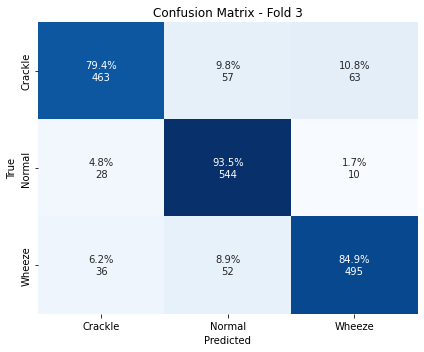

              precision    recall  f1-score   support

     Crackle       0.88      0.79      0.83       583
      Normal       0.83      0.93      0.88       582
      Wheeze       0.87      0.85      0.86       583

    accuracy                           0.86      1748
   macro avg       0.86      0.86      0.86      1748
weighted avg       0.86      0.86      0.86      1748


Fold 4


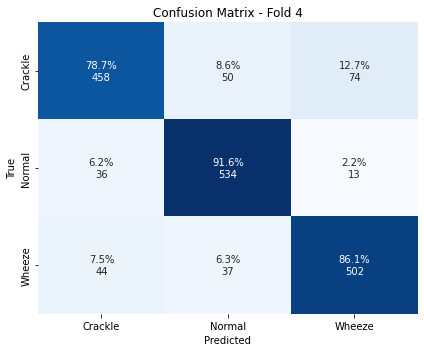

              precision    recall  f1-score   support

     Crackle       0.85      0.79      0.82       582
      Normal       0.86      0.92      0.89       583
      Wheeze       0.85      0.86      0.86       583

    accuracy                           0.85      1748
   macro avg       0.85      0.85      0.85      1748
weighted avg       0.85      0.85      0.85      1748


Fold 5


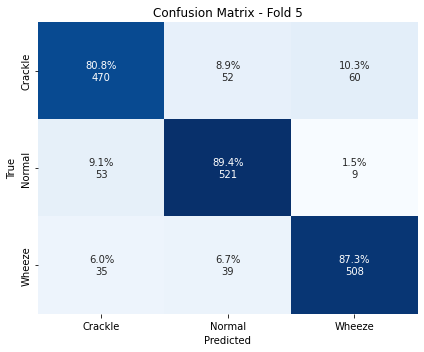

              precision    recall  f1-score   support

     Crackle       0.84      0.81      0.82       582
      Normal       0.85      0.89      0.87       583
      Wheeze       0.88      0.87      0.88       582

    accuracy                           0.86      1747
   macro avg       0.86      0.86      0.86      1747
weighted avg       0.86      0.86      0.86      1747



In [ ]:
from statistical_models.xgboost import *

xgb_model = train(X_train, y_train, classes, best_params_xgb)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.72      0.69      0.70       373
      Normal       0.78      0.84      0.81       729
      Wheeze       0.75      0.59      0.66       177

    accuracy                           0.76      1279
   macro avg       0.75      0.71      0.72      1279
weighted avg       0.76      0.76      0.76      1279



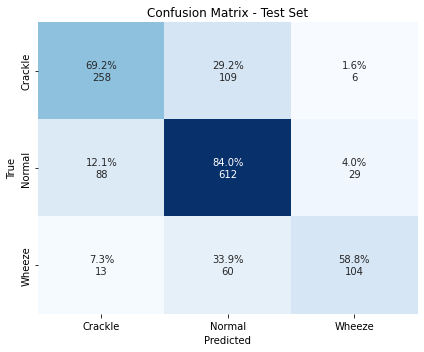

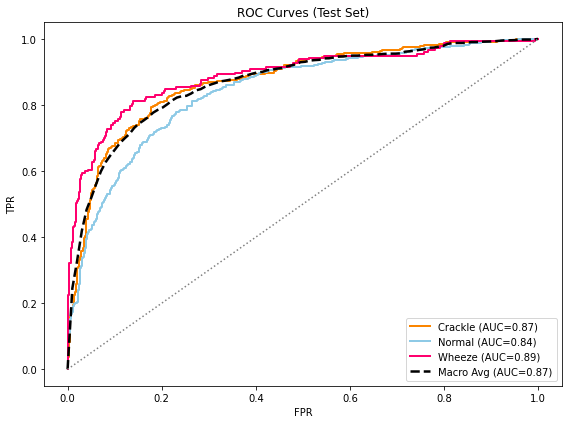

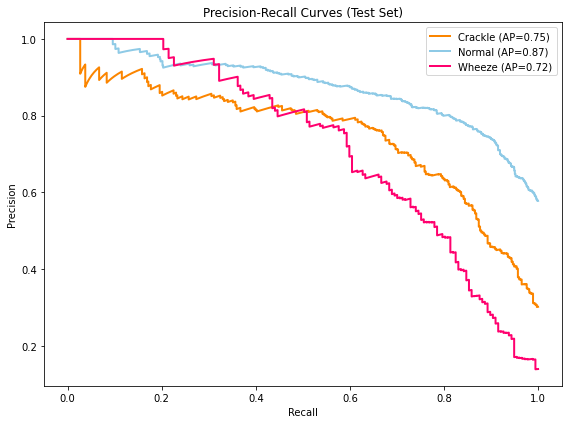

In [27]:
xgb_cdan_metrics_df = evaluate_model(X_test, y_test, classes, xgb_model)

In [28]:
xgb_cdan_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.691689,0.888521,0.718663,0.875000,0.586898,0.790105
1,Normal,0.839506,0.692727,0.783611,0.765060,0.540390,0.766117
2,Wheeze,0.587571,0.968240,0.748201,0.935965,0.616658,0.777905


#### **DANN with VAE**

1 Phase training

In [ ]:
X_train = np.load("davae_embeddings_train.npy")
y_train = np.load("training_labels.npy")
X_test = np.load("davae_embeddings_test.npy")
y_test = np.load("test_labels.npy")

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
classes = le.classes_

# Apply MinMax Scaling 
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Fold 1


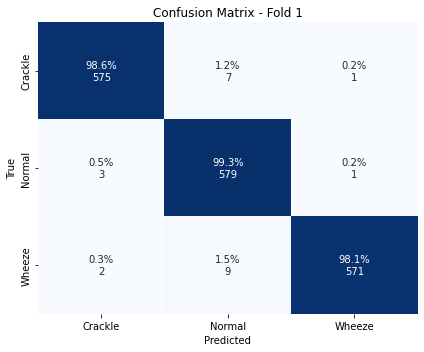

              precision    recall  f1-score   support

     Crackle       0.99      0.99      0.99       583
      Normal       0.97      0.99      0.98       583
      Wheeze       1.00      0.98      0.99       582

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 2


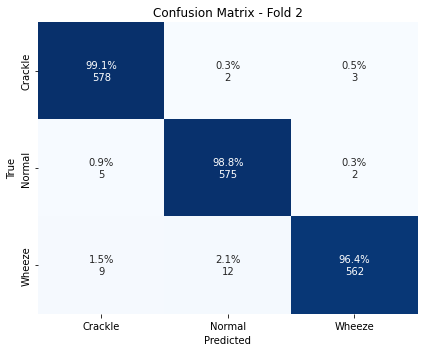

              precision    recall  f1-score   support

     Crackle       0.98      0.99      0.98       583
      Normal       0.98      0.99      0.98       582
      Wheeze       0.99      0.96      0.98       583

    accuracy                           0.98      1748
   macro avg       0.98      0.98      0.98      1748
weighted avg       0.98      0.98      0.98      1748


Fold 3


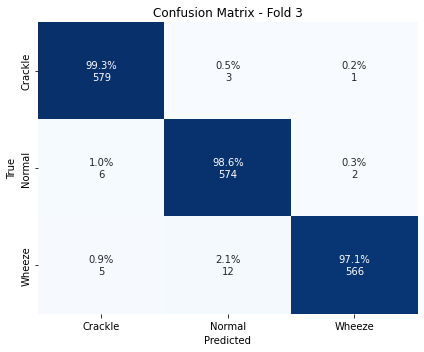

              precision    recall  f1-score   support

     Crackle       0.98      0.99      0.99       583
      Normal       0.97      0.99      0.98       582
      Wheeze       0.99      0.97      0.98       583

    accuracy                           0.98      1748
   macro avg       0.98      0.98      0.98      1748
weighted avg       0.98      0.98      0.98      1748


Fold 4


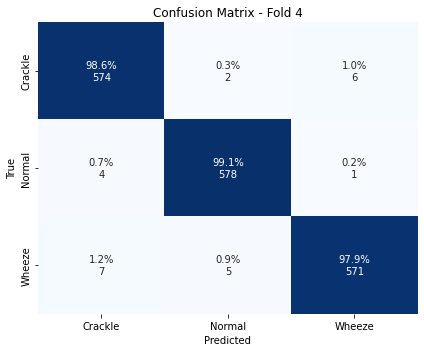

              precision    recall  f1-score   support

     Crackle       0.98      0.99      0.98       582
      Normal       0.99      0.99      0.99       583
      Wheeze       0.99      0.98      0.98       583

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 5


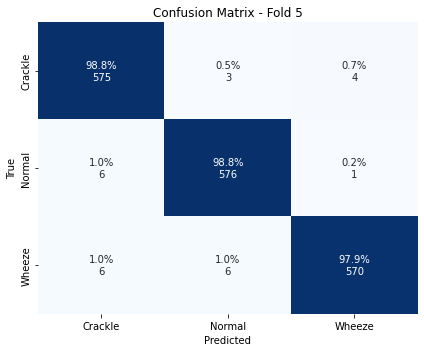

              precision    recall  f1-score   support

     Crackle       0.98      0.99      0.98       582
      Normal       0.98      0.99      0.99       583
      Wheeze       0.99      0.98      0.99       582

    accuracy                           0.99      1747
   macro avg       0.99      0.99      0.99      1747
weighted avg       0.99      0.99      0.99      1747



In [ ]:
from statistical_models.knn import *

knn_model = train(X_train, y_train, classes, n_neighbors=best_k)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.68      0.68      0.68       373
      Normal       0.79      0.81      0.80       729
      Wheeze       0.70      0.62      0.66       177

    accuracy                           0.75      1279
   macro avg       0.72      0.70      0.71      1279
weighted avg       0.74      0.75      0.74      1279



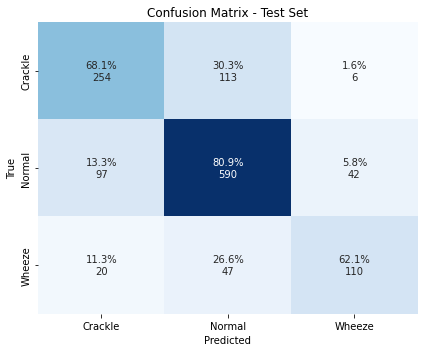

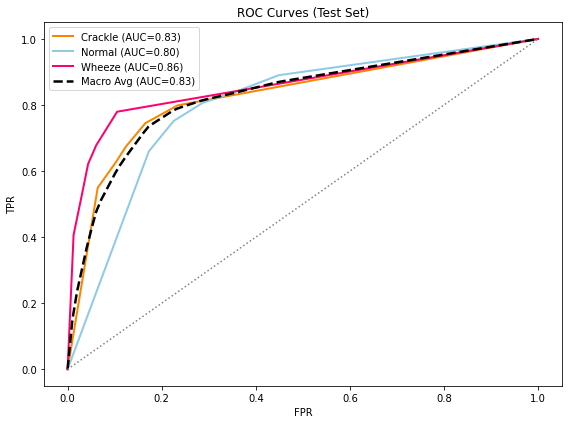

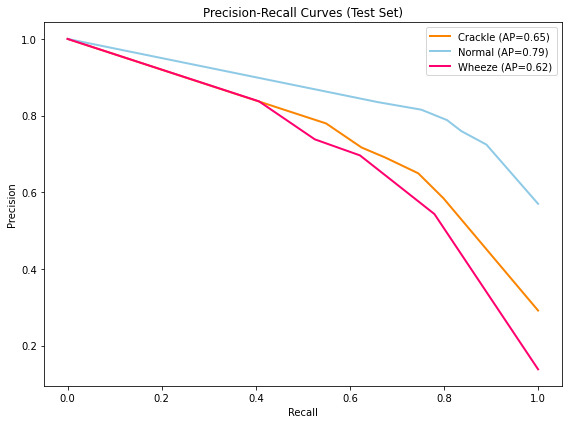

In [34]:
from statistical_models.evaluate import evaluate_model

# Evaluate on test set
knn_davae_1_metrics_df = evaluate_model(X_test, y_test, classes, knn_model)

In [35]:
knn_davae_1_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.680965,0.870861,0.684636,0.868943,0.552702,0.775913
1,Normal,0.809328,0.709091,0.786667,0.737240,0.521156,0.759209
2,Wheeze,0.621469,0.956443,0.696203,0.940232,0.606468,0.788956



Fold 1


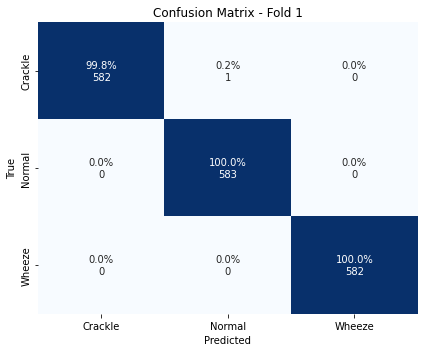

              precision    recall  f1-score   support

     Crackle       1.00      1.00      1.00       583
      Normal       1.00      1.00      1.00       583
      Wheeze       1.00      1.00      1.00       582

    accuracy                           1.00      1748
   macro avg       1.00      1.00      1.00      1748
weighted avg       1.00      1.00      1.00      1748


Fold 2


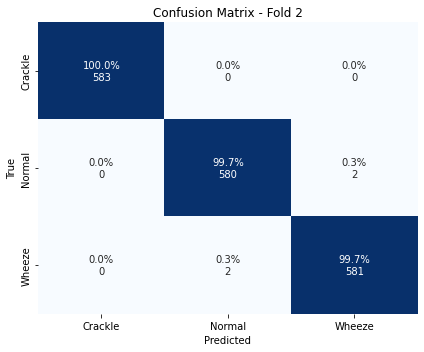

              precision    recall  f1-score   support

     Crackle       1.00      1.00      1.00       583
      Normal       1.00      1.00      1.00       582
      Wheeze       1.00      1.00      1.00       583

    accuracy                           1.00      1748
   macro avg       1.00      1.00      1.00      1748
weighted avg       1.00      1.00      1.00      1748


Fold 3


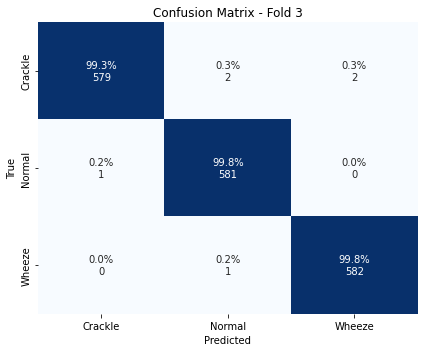

              precision    recall  f1-score   support

     Crackle       1.00      0.99      1.00       583
      Normal       0.99      1.00      1.00       582
      Wheeze       1.00      1.00      1.00       583

    accuracy                           1.00      1748
   macro avg       1.00      1.00      1.00      1748
weighted avg       1.00      1.00      1.00      1748


Fold 4


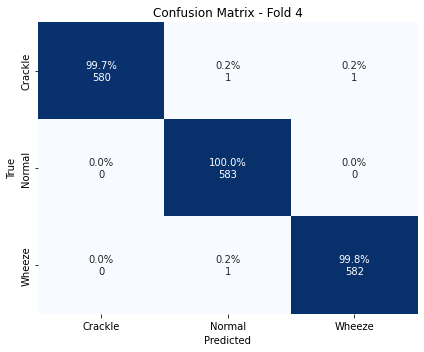

              precision    recall  f1-score   support

     Crackle       1.00      1.00      1.00       582
      Normal       1.00      1.00      1.00       583
      Wheeze       1.00      1.00      1.00       583

    accuracy                           1.00      1748
   macro avg       1.00      1.00      1.00      1748
weighted avg       1.00      1.00      1.00      1748


Fold 5


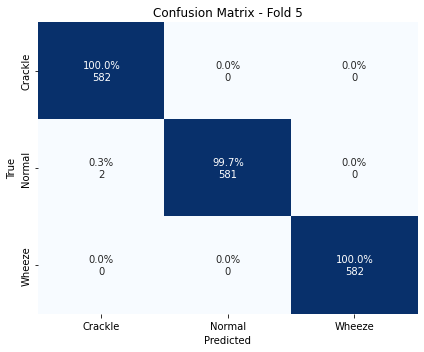

              precision    recall  f1-score   support

     Crackle       1.00      1.00      1.00       582
      Normal       1.00      1.00      1.00       583
      Wheeze       1.00      1.00      1.00       582

    accuracy                           1.00      1747
   macro avg       1.00      1.00      1.00      1747
weighted avg       1.00      1.00      1.00      1747



In [ ]:
from statistical_models.non_linear_svm import *

svm_model = train(X_train, y_train, classes, best_params_svm)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.68      0.66      0.67       373
      Normal       0.78      0.79      0.79       729
      Wheeze       0.64      0.67      0.65       177

    accuracy                           0.73      1279
   macro avg       0.70      0.70      0.70      1279
weighted avg       0.73      0.73      0.73      1279



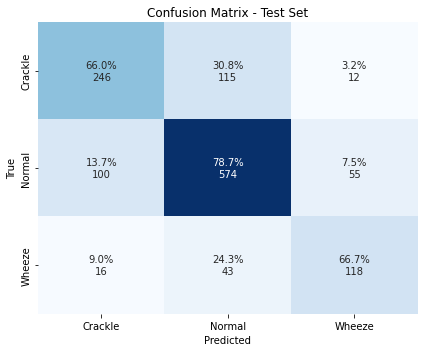

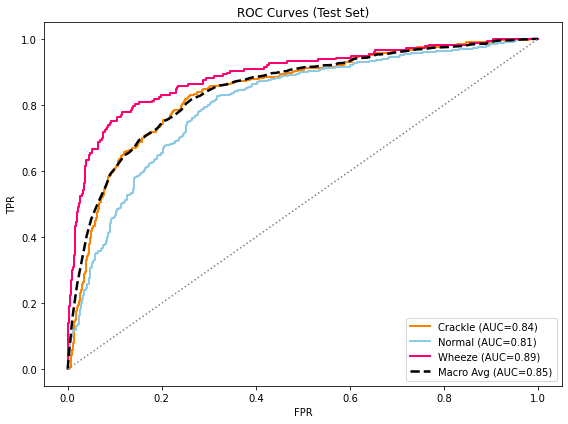

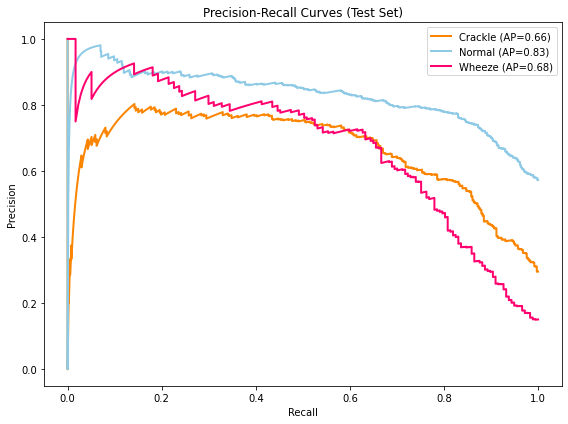

In [58]:
from statistical_models.evaluate import evaluate_model

svm_davae_1_metrics_df = evaluate_model(X_test, y_test, classes, svm_model)

In [59]:
svm_davae_1_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.659517,0.871965,0.679558,0.861505,0.536251,0.765741
1,Normal,0.787380,0.712727,0.784153,0.716636,0.500448,0.750054
2,Wheeze,0.666667,0.939201,0.637838,0.946069,0.594786,0.802934



Fold 1


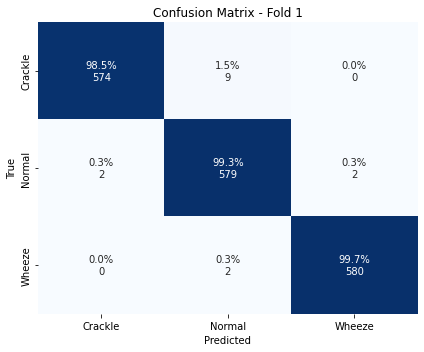

              precision    recall  f1-score   support

     Crackle       1.00      0.98      0.99       583
      Normal       0.98      0.99      0.99       583
      Wheeze       1.00      1.00      1.00       582

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 2


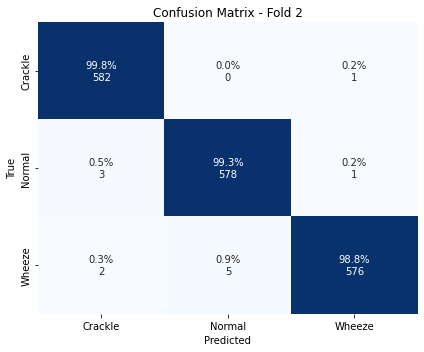

              precision    recall  f1-score   support

     Crackle       0.99      1.00      0.99       583
      Normal       0.99      0.99      0.99       582
      Wheeze       1.00      0.99      0.99       583

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 3


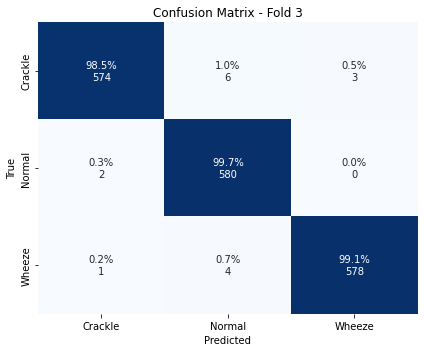

              precision    recall  f1-score   support

     Crackle       0.99      0.98      0.99       583
      Normal       0.98      1.00      0.99       582
      Wheeze       0.99      0.99      0.99       583

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 4


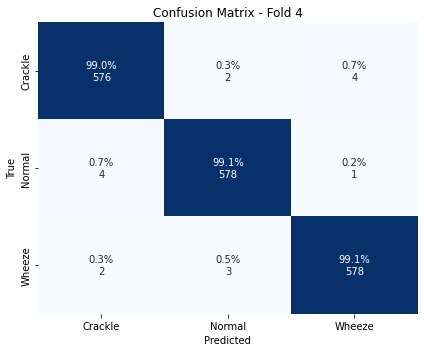

              precision    recall  f1-score   support

     Crackle       0.99      0.99      0.99       582
      Normal       0.99      0.99      0.99       583
      Wheeze       0.99      0.99      0.99       583

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 5


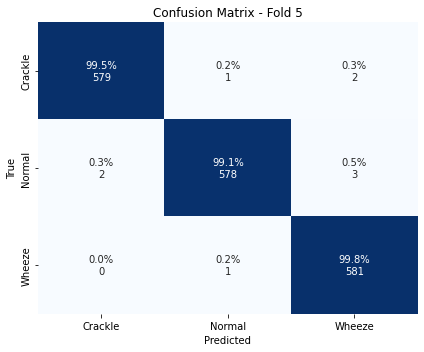

              precision    recall  f1-score   support

     Crackle       1.00      0.99      1.00       582
      Normal       1.00      0.99      0.99       583
      Wheeze       0.99      1.00      0.99       582

    accuracy                           0.99      1747
   macro avg       0.99      0.99      0.99      1747
weighted avg       0.99      0.99      0.99      1747



In [ ]:
from statistical_models.random_forest import *

rf_model = train(X_train, y_train, classes, best_params_rf)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.69      0.67      0.68       373
      Normal       0.79      0.79      0.79       729
      Wheeze       0.66      0.68      0.67       177

    accuracy                           0.74      1279
   macro avg       0.71      0.71      0.71      1279
weighted avg       0.74      0.74      0.74      1279



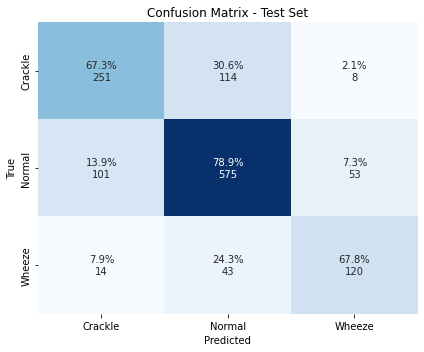

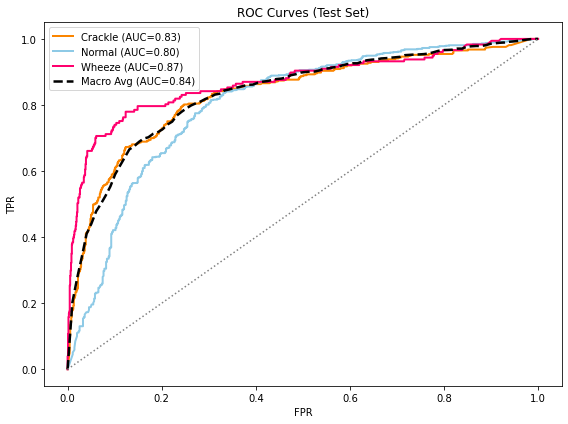

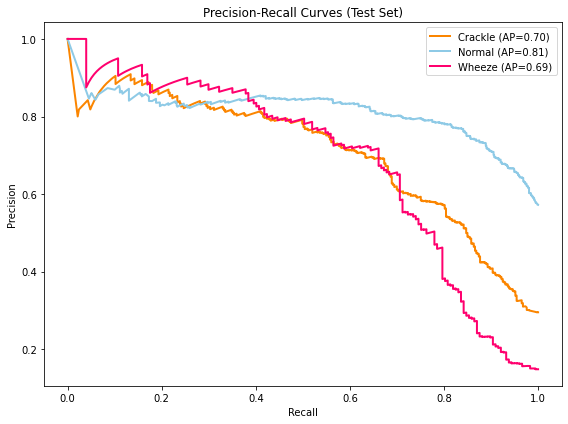

In [50]:
rf_davae_1_metrics_df = evaluate_model(X_test, y_test, classes, rf_model)

In [51]:
rf_davae_1_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.672922,0.873068,0.685792,0.866375,0.549070,0.772995
1,Normal,0.788752,0.714545,0.785519,0.718464,0.503640,0.751649
2,Wheeze,0.677966,0.944646,0.662983,0.948087,0.616815,0.811306



Fold 1


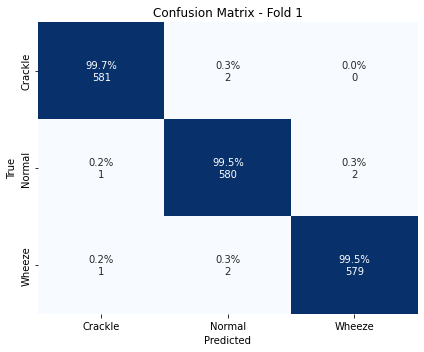

              precision    recall  f1-score   support

     Crackle       1.00      1.00      1.00       583
      Normal       0.99      0.99      0.99       583
      Wheeze       1.00      0.99      1.00       582

    accuracy                           1.00      1748
   macro avg       1.00      1.00      1.00      1748
weighted avg       1.00      1.00      1.00      1748


Fold 2


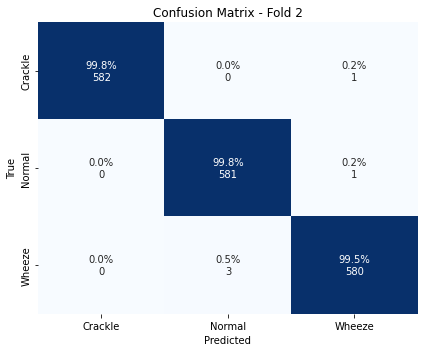

              precision    recall  f1-score   support

     Crackle       1.00      1.00      1.00       583
      Normal       0.99      1.00      1.00       582
      Wheeze       1.00      0.99      1.00       583

    accuracy                           1.00      1748
   macro avg       1.00      1.00      1.00      1748
weighted avg       1.00      1.00      1.00      1748


Fold 3


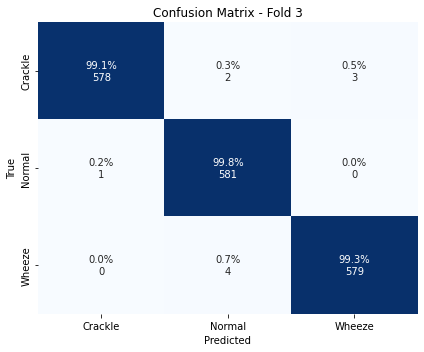

              precision    recall  f1-score   support

     Crackle       1.00      0.99      0.99       583
      Normal       0.99      1.00      0.99       582
      Wheeze       0.99      0.99      0.99       583

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 4


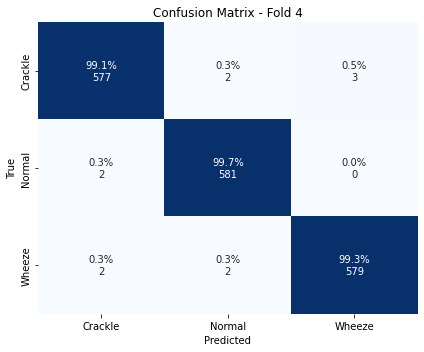

              precision    recall  f1-score   support

     Crackle       0.99      0.99      0.99       582
      Normal       0.99      1.00      0.99       583
      Wheeze       0.99      0.99      0.99       583

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 5


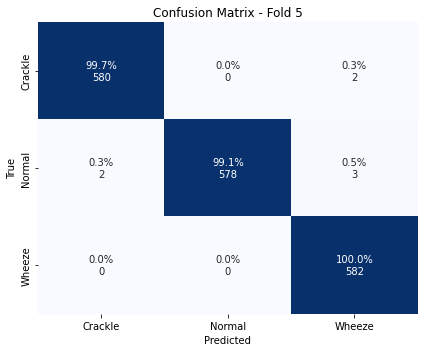

              precision    recall  f1-score   support

     Crackle       1.00      1.00      1.00       582
      Normal       1.00      0.99      1.00       583
      Wheeze       0.99      1.00      1.00       582

    accuracy                           1.00      1747
   macro avg       1.00      1.00      1.00      1747
weighted avg       1.00      1.00      1.00      1747



In [ ]:
from statistical_models.xgboost import *

xgb_model = train(X_train, y_train, classes, best_params_xgb)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.66      0.66      0.66       373
      Normal       0.78      0.78      0.78       729
      Wheeze       0.65      0.66      0.65       177

    accuracy                           0.73      1279
   macro avg       0.70      0.70      0.70      1279
weighted avg       0.73      0.73      0.73      1279



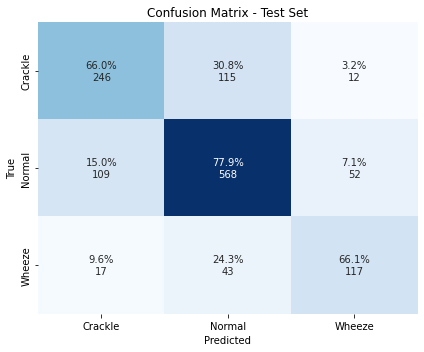

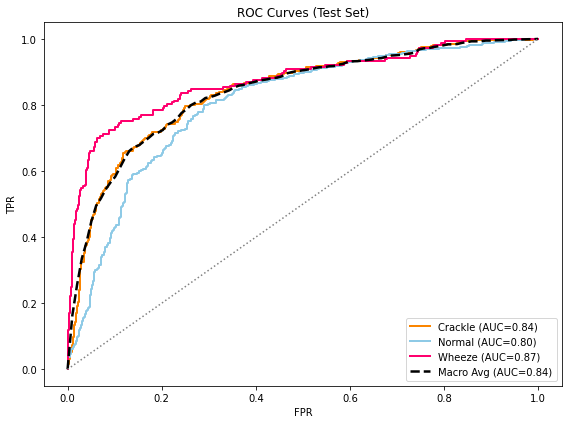

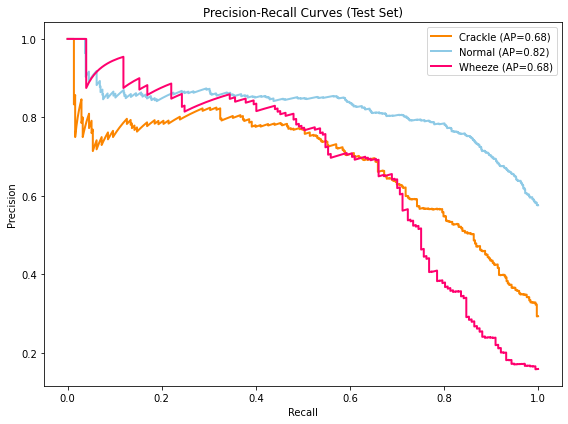

In [53]:
xgb_davae_1_metrics_df = evaluate_model(X_test, y_test, classes, xgb_model)

In [55]:
xgb_davae_1_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.659517,0.860927,0.661290,0.859978,0.520856,0.760222
1,Normal,0.779150,0.712727,0.782369,0.708861,0.491553,0.745938
2,Wheeze,0.661017,0.941924,0.646409,0.945355,0.597326,0.801470


2 Phase training

In [ ]:
X_train = np.load("davae_embeddings_train_2.npy")
y_train = np.load("training_labels.npy")
X_test = np.load("davae_embeddings_test_2.npy")
y_test = np.load("test_labels.npy")

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
classes = le.classes_

scaler = MinMaxScaler(feature_range=(-1, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Fold 1


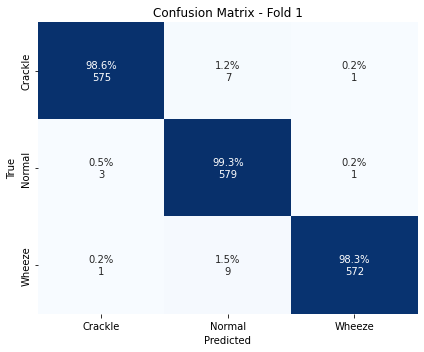

              precision    recall  f1-score   support

     Crackle       0.99      0.99      0.99       583
      Normal       0.97      0.99      0.98       583
      Wheeze       1.00      0.98      0.99       582

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 2


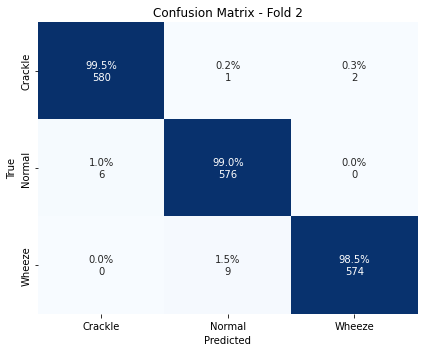

              precision    recall  f1-score   support

     Crackle       0.99      0.99      0.99       583
      Normal       0.98      0.99      0.99       582
      Wheeze       1.00      0.98      0.99       583

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 3


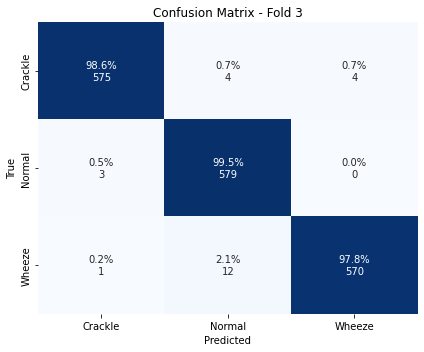

              precision    recall  f1-score   support

     Crackle       0.99      0.99      0.99       583
      Normal       0.97      0.99      0.98       582
      Wheeze       0.99      0.98      0.99       583

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 4


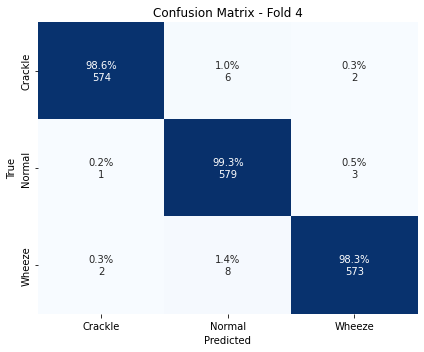

              precision    recall  f1-score   support

     Crackle       0.99      0.99      0.99       582
      Normal       0.98      0.99      0.98       583
      Wheeze       0.99      0.98      0.99       583

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 5


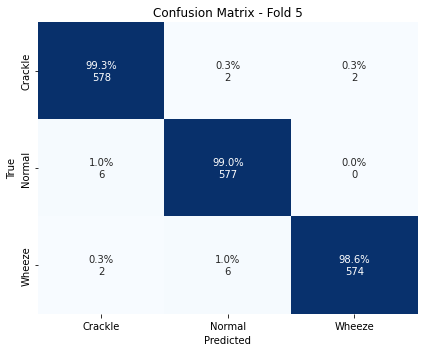

              precision    recall  f1-score   support

     Crackle       0.99      0.99      0.99       582
      Normal       0.99      0.99      0.99       583
      Wheeze       1.00      0.99      0.99       582

    accuracy                           0.99      1747
   macro avg       0.99      0.99      0.99      1747
weighted avg       0.99      0.99      0.99      1747



In [ ]:
from statistical_models.knn import *

knn_model = train(X_train, y_train, classes, n_neighbors=best_k)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.67      0.70      0.69       373
      Normal       0.79      0.80      0.79       729
      Wheeze       0.70      0.63      0.66       177

    accuracy                           0.75      1279
   macro avg       0.72      0.71      0.71      1279
weighted avg       0.75      0.75      0.74      1279



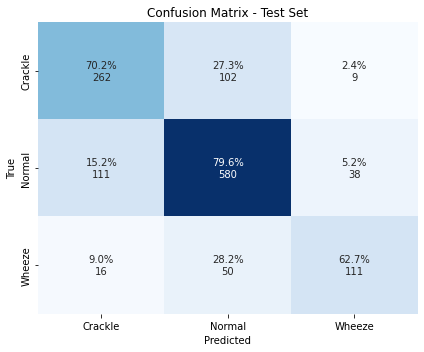

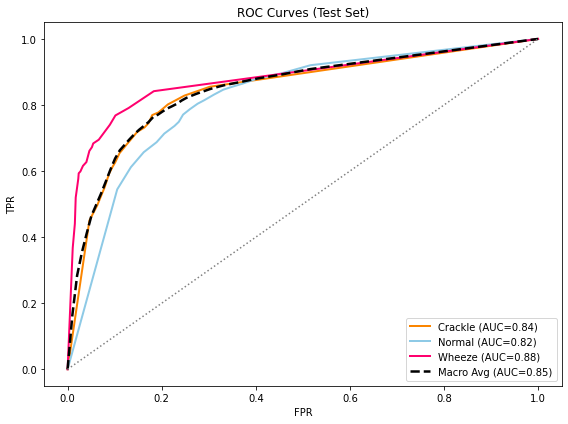

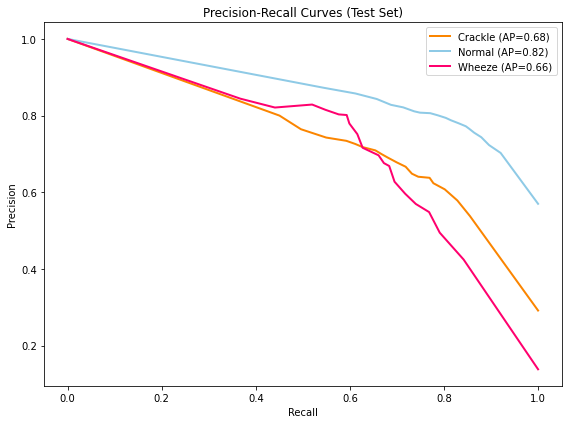

In [46]:
from statistical_models.evaluate import evaluate_model

# Evaluate on test set
knn_davae_2_metrics_df = evaluate_model(X_test, y_test, classes, knn_model)

In [47]:
knn_davae_2_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.702413,0.859823,0.673522,0.875281,0.555479,0.781118
1,Normal,0.795610,0.723636,0.792350,0.727605,0.519601,0.759623
2,Wheeze,0.627119,0.957350,0.702532,0.941124,0.613349,0.792234



Fold 1


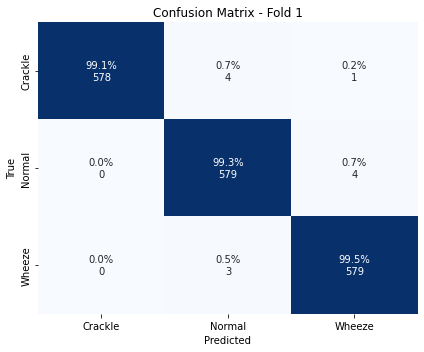

              precision    recall  f1-score   support

     Crackle       1.00      0.99      1.00       583
      Normal       0.99      0.99      0.99       583
      Wheeze       0.99      0.99      0.99       582

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 2


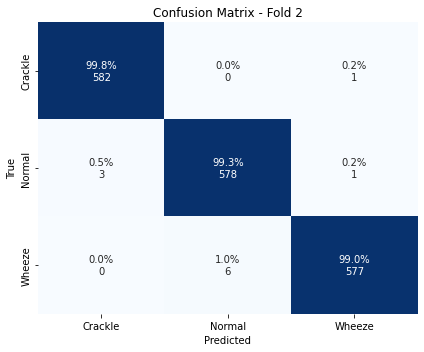

              precision    recall  f1-score   support

     Crackle       0.99      1.00      1.00       583
      Normal       0.99      0.99      0.99       582
      Wheeze       1.00      0.99      0.99       583

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 3


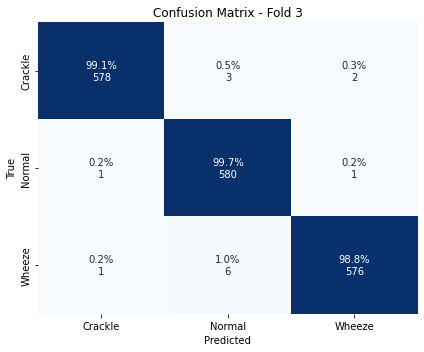

              precision    recall  f1-score   support

     Crackle       1.00      0.99      0.99       583
      Normal       0.98      1.00      0.99       582
      Wheeze       0.99      0.99      0.99       583

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 4


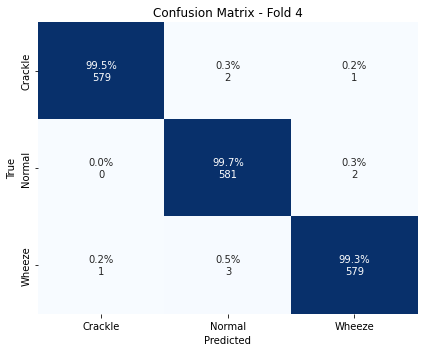

              precision    recall  f1-score   support

     Crackle       1.00      0.99      1.00       582
      Normal       0.99      1.00      0.99       583
      Wheeze       0.99      0.99      0.99       583

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 5


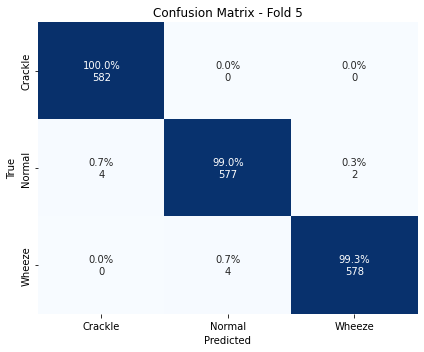

              precision    recall  f1-score   support

     Crackle       0.99      1.00      1.00       582
      Normal       0.99      0.99      0.99       583
      Wheeze       1.00      0.99      0.99       582

    accuracy                           0.99      1747
   macro avg       0.99      0.99      0.99      1747
weighted avg       0.99      0.99      0.99      1747



In [ ]:
from statistical_models.non_linear_svm import *

svm_model = train(X_train, y_train, classes, best_params_svm)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.68      0.66      0.67       373
      Normal       0.78      0.78      0.78       729
      Wheeze       0.65      0.67      0.66       177

    accuracy                           0.73      1279
   macro avg       0.70      0.70      0.70      1279
weighted avg       0.73      0.73      0.73      1279



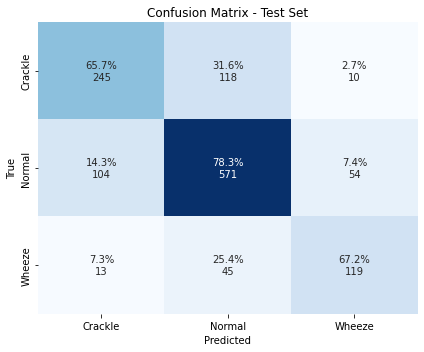

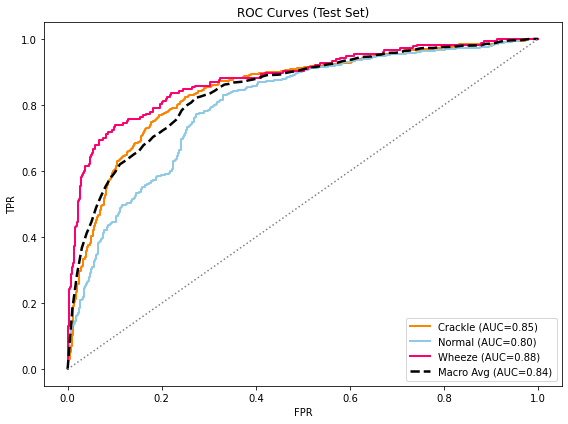

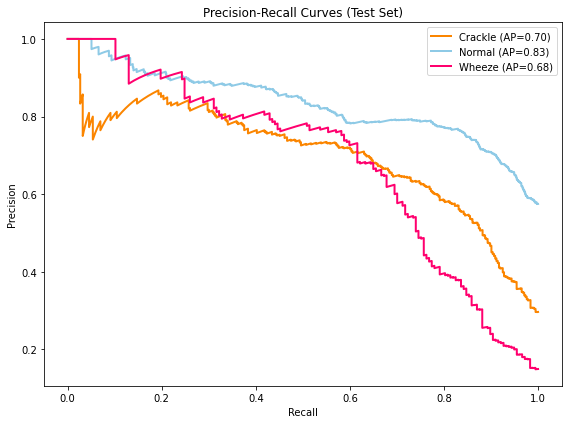

In [62]:
from statistical_models.evaluate import evaluate_model

svm_davae_2_metrics_df = evaluate_model(X_test, y_test, classes, svm_model)

In [63]:
svm_davae_2_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.656836,0.870861,0.676796,0.860414,0.532432,0.763849
1,Normal,0.783265,0.703636,0.777929,0.710092,0.487461,0.743451
2,Wheeze,0.672316,0.941924,0.650273,0.947080,0.605738,0.807120



Fold 1


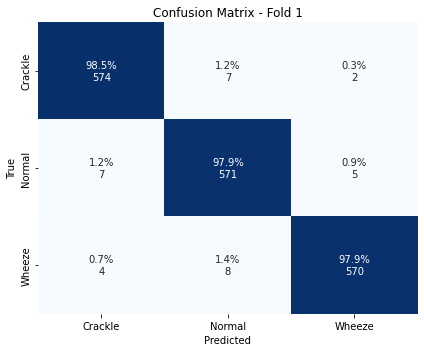

              precision    recall  f1-score   support

     Crackle       0.98      0.98      0.98       583
      Normal       0.97      0.98      0.98       583
      Wheeze       0.99      0.98      0.98       582

    accuracy                           0.98      1748
   macro avg       0.98      0.98      0.98      1748
weighted avg       0.98      0.98      0.98      1748


Fold 2


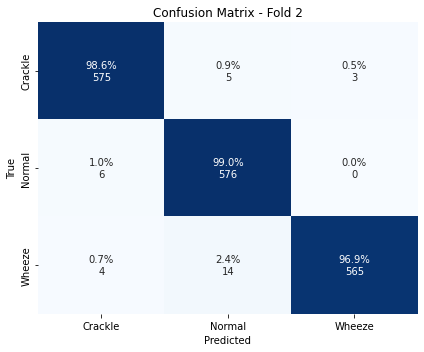

              precision    recall  f1-score   support

     Crackle       0.98      0.99      0.98       583
      Normal       0.97      0.99      0.98       582
      Wheeze       0.99      0.97      0.98       583

    accuracy                           0.98      1748
   macro avg       0.98      0.98      0.98      1748
weighted avg       0.98      0.98      0.98      1748


Fold 3


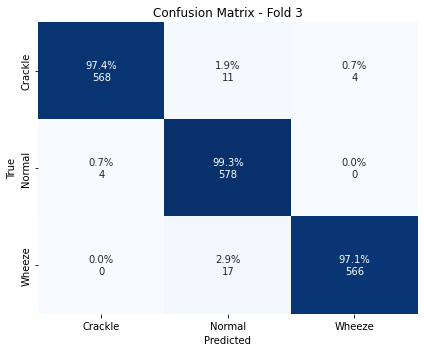

              precision    recall  f1-score   support

     Crackle       0.99      0.97      0.98       583
      Normal       0.95      0.99      0.97       582
      Wheeze       0.99      0.97      0.98       583

    accuracy                           0.98      1748
   macro avg       0.98      0.98      0.98      1748
weighted avg       0.98      0.98      0.98      1748


Fold 4


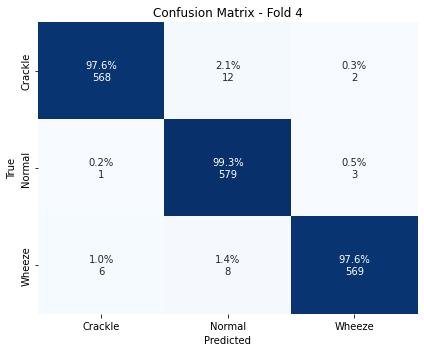

              precision    recall  f1-score   support

     Crackle       0.99      0.98      0.98       582
      Normal       0.97      0.99      0.98       583
      Wheeze       0.99      0.98      0.98       583

    accuracy                           0.98      1748
   macro avg       0.98      0.98      0.98      1748
weighted avg       0.98      0.98      0.98      1748


Fold 5


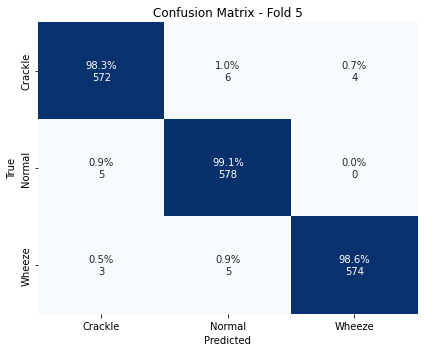

              precision    recall  f1-score   support

     Crackle       0.99      0.98      0.98       582
      Normal       0.98      0.99      0.99       583
      Wheeze       0.99      0.99      0.99       582

    accuracy                           0.99      1747
   macro avg       0.99      0.99      0.99      1747
weighted avg       0.99      0.99      0.99      1747



In [ ]:
from statistical_models.random_forest import *

rf_model = train(X_train, y_train, classes, best_params_rf)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.68      0.65      0.66       373
      Normal       0.78      0.81      0.80       729
      Wheeze       0.69      0.64      0.66       177

    accuracy                           0.74      1279
   macro avg       0.72      0.70      0.71      1279
weighted avg       0.74      0.74      0.74      1279



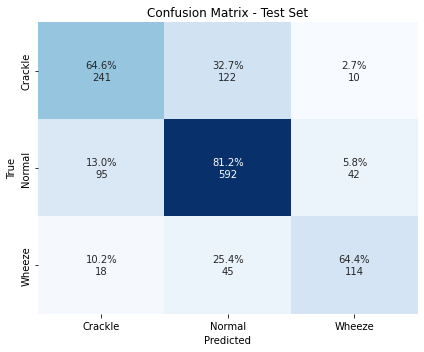

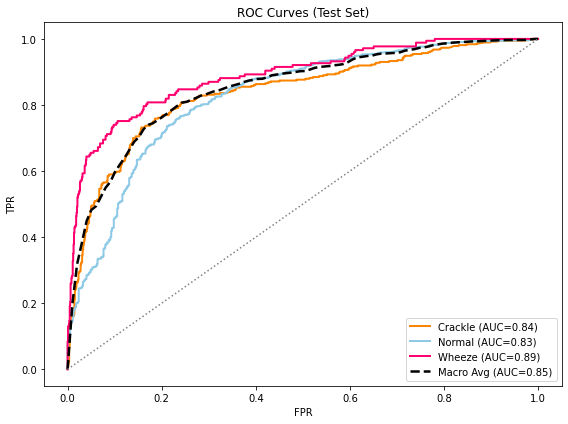

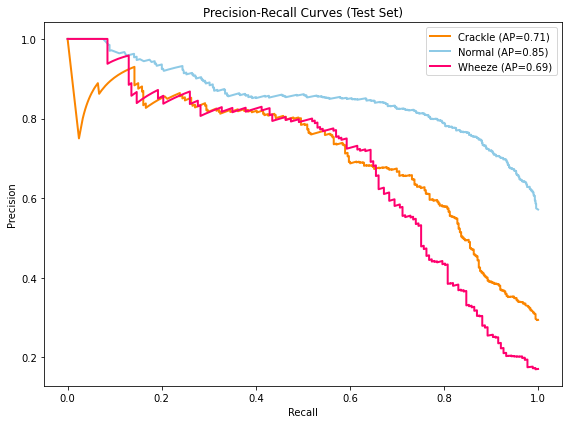

In [65]:
rf_davae_2_metrics_df = evaluate_model(X_test, y_test, classes, rf_model)

In [66]:
rf_davae_2_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.646113,0.875276,0.680791,0.857297,0.529673,0.760694
1,Normal,0.812071,0.696364,0.779974,0.736538,0.512458,0.754217
2,Wheeze,0.644068,0.952813,0.686747,0.943396,0.613287,0.798440



Fold 1


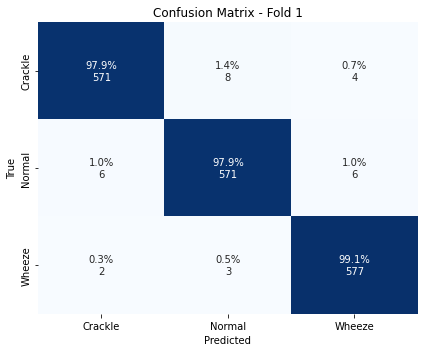

              precision    recall  f1-score   support

     Crackle       0.99      0.98      0.98       583
      Normal       0.98      0.98      0.98       583
      Wheeze       0.98      0.99      0.99       582

    accuracy                           0.98      1748
   macro avg       0.98      0.98      0.98      1748
weighted avg       0.98      0.98      0.98      1748


Fold 2


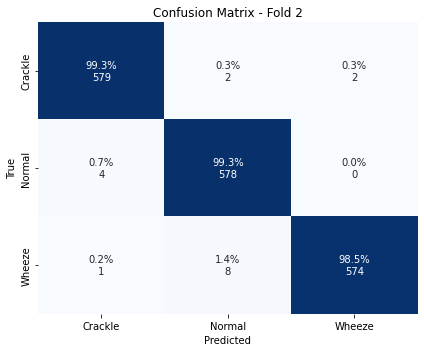

              precision    recall  f1-score   support

     Crackle       0.99      0.99      0.99       583
      Normal       0.98      0.99      0.99       582
      Wheeze       1.00      0.98      0.99       583

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 3


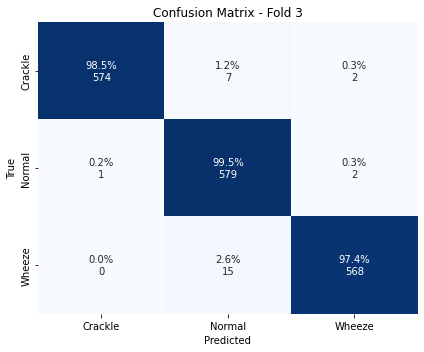

              precision    recall  f1-score   support

     Crackle       1.00      0.98      0.99       583
      Normal       0.96      0.99      0.98       582
      Wheeze       0.99      0.97      0.98       583

    accuracy                           0.98      1748
   macro avg       0.98      0.98      0.98      1748
weighted avg       0.98      0.98      0.98      1748


Fold 4


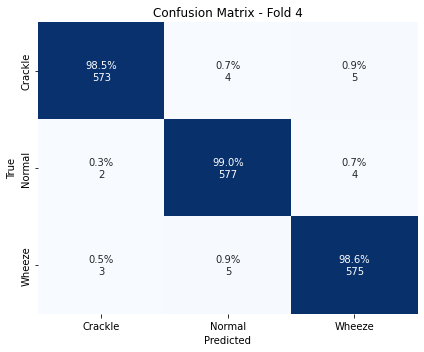

              precision    recall  f1-score   support

     Crackle       0.99      0.98      0.99       582
      Normal       0.98      0.99      0.99       583
      Wheeze       0.98      0.99      0.99       583

    accuracy                           0.99      1748
   macro avg       0.99      0.99      0.99      1748
weighted avg       0.99      0.99      0.99      1748


Fold 5


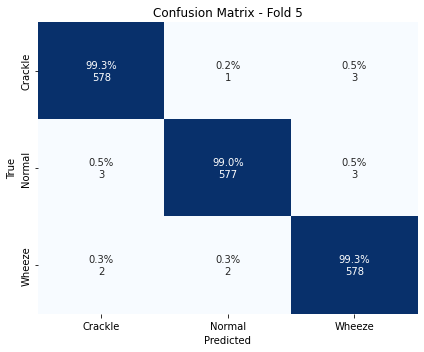

              precision    recall  f1-score   support

     Crackle       0.99      0.99      0.99       582
      Normal       0.99      0.99      0.99       583
      Wheeze       0.99      0.99      0.99       582

    accuracy                           0.99      1747
   macro avg       0.99      0.99      0.99      1747
weighted avg       0.99      0.99      0.99      1747



In [ ]:
from statistical_models.xgboost import *

xgb_model = train(X_train, y_train, classes, best_params_xgb)


Classification Report (Test Set):
              precision    recall  f1-score   support

     Crackle       0.68      0.65      0.66       373
      Normal       0.78      0.80      0.79       729
      Wheeze       0.66      0.66      0.66       177

    accuracy                           0.74      1279
   macro avg       0.71      0.70      0.70      1279
weighted avg       0.74      0.74      0.74      1279



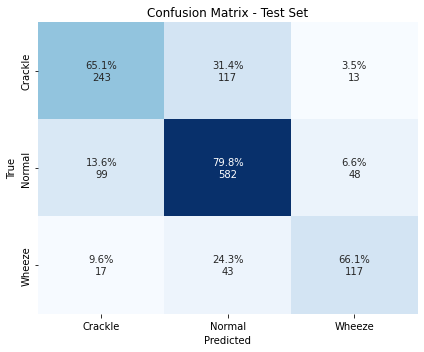

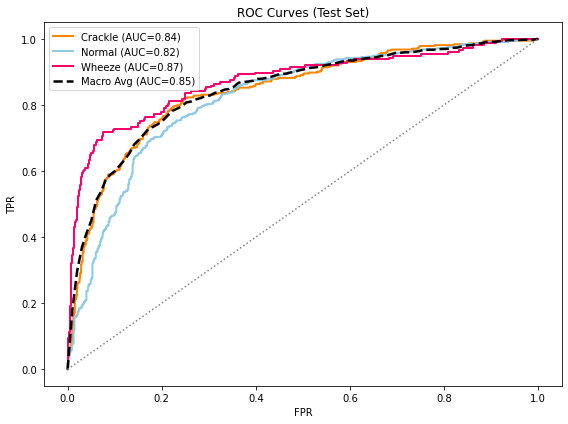

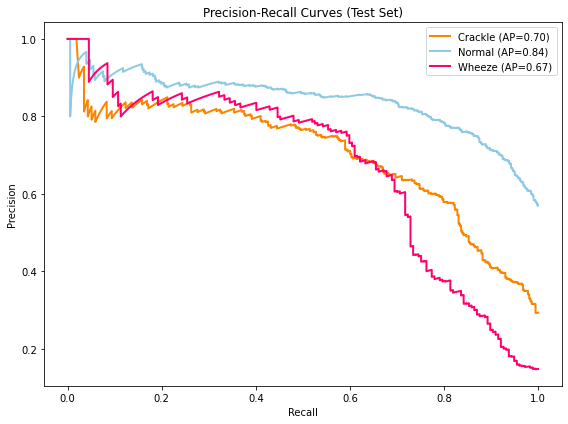

In [68]:
xgb_davae_2_metrics_df = evaluate_model(X_test, y_test, classes, xgb_model)

In [69]:
xgb_davae_2_metrics_df

,Class,Sensitivity (SE),Specificity (SP),PPV,NPV,MCC,SCORE
0,Crackle,0.651475,0.871965,0.676880,0.858696,0.529473,0.761720
1,Normal,0.798354,0.709091,0.784367,0.726257,0.509032,0.753722
2,Wheeze,0.661017,0.944646,0.657303,0.945504,0.604234,0.802832
